# Logistic Regression: Zero to Hero

The most widely deployed classifier in the world, and the one most often misread.

> **Prerequisite: [`ml_foundations_zero_to_hero.ipynb`](ml_foundations_zero_to_hero.ipynb).**
> That notebook covers the half of the job that is the same for every model — splitting,
> leakage, pipelines, messy data, metrics, tuning, shipping. This one assumes you have read
> it and covers only what is specific to logistic regression. Where a topic is introduced
> there, we go deeper here rather than repeating it.

***

## Why this model still matters

It is 70 years old and it is still the default in credit scoring, clinical risk, insurance
pricing and ad ranking. Not because it is the most accurate — it usually is not — but
because:

- it outputs a **probability**, and one that is usually well calibrated when the log-odds
  specification is reasonable — worth checking rather than assuming
- every coefficient converts to a sentence a regulator or clinician can audit
- it trains in milliseconds and scores in microseconds on any hardware
- when a boosted tree beats it by two points, you can ask whether two points is worth losing
  all of the above

## Contents

| Part | What it covers |
|---|---|
| **0. Setup** | Install + imports |
| **1. Theory from zero** | Sigmoid, log-odds, why squared error is the *wrong* loss, fitting from scratch, odds ratios, regularization, multiclass |
| **2. Worked example** | Customer churn, end to end, on imbalanced mixed-type data |
| **3. Thresholds & calibration** | The deep version of what Foundations introduced — and where most real mistakes happen |
| **4. Tough questions** | 12 questions + 3 coding challenges |
| **5. Practice datasets** | 5 datasets with briefs |
| **6. Reading the literature** | The papers behind each section |
| **Appendix** | Errors specific to this model |

## The one-paragraph summary

Logistic regression computes the **same weighted sum as linear regression**, then squashes it
through the sigmoid to get a probability. It is fitted by maximising the likelihood of the
observed labels (equivalently, minimising log-loss), which has no closed-form solution, so it
is solved iteratively. Each coefficient is a **log-odds** effect, so exponentiating it gives
an odds ratio. The model outputs a probability; turning that into a decision requires a
**threshold**, and choosing that threshold is a separate problem with a separate answer.

***
# Part 0 - Setup

In [1]:
# ---------------------------------------------------------------------------
# One-time setup. Only missing packages are installed, so re-running is cheap.
# ---------------------------------------------------------------------------
import importlib.util
import subprocess
import sys

REQUIRED = [
    ("numpy", "numpy"), ("pandas", "pandas"), ("matplotlib", "matplotlib"),
    ("scipy", "scipy"), ("sklearn", "scikit-learn"),
]
missing = [pip for mod, pip in REQUIRED if importlib.util.find_spec(mod) is None]
if missing:
    print("installing:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("done")
else:
    print("all packages present")

all packages present


In [2]:
# ---------------------------------------------------------------------------
# Every import this notebook uses.
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit          # the sigmoid, 1 / (1 + e**-z), numerically stable

from sklearn.datasets import make_classification, load_breast_cancer, load_wine, load_digits
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate, StratifiedKFold,
    GridSearchCV, TunedThresholdClassifierCV,
)
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV, SGDClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, log_loss, brier_score_loss,
    confusion_matrix, classification_report, precision_recall_curve, roc_curve,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110

print("ready | numpy", np.__version__, "| pandas", pd.__version__)

ready | numpy 2.5.2 | pandas 3.0.5


***
# Part 1 - Theory from zero

1. Why you cannot just run linear regression on a 0/1 target
2. The sigmoid and the log-odds link
3. The loss: why **not** squared error, and where log-loss comes from
4. Fitting it: no closed form, so gradient descent — from scratch
5. Reading the coefficients: odds ratios
6. Regularization, and sklearn's confusing `C`
7. More than two classes

## 1.1 Why not just use linear regression?

The target is 0 or 1. Linear regression fits $\hat{y} = w^\top x + b$, which is a straight
line over the whole real number line. Fitting that to a binary target — the *linear
probability model* — is a real and sometimes defensible technique, widely used in economics
where the coefficients are the quantity of interest and marginal effects are what matter. For
*probabilistic classification*, which is what this notebook is about, three things go wrong:

1. **Predictions leave $[0,1]$.** A "probability" of 1.4 or −0.3 is not a probability, and
   any expected-value calculation downstream is now nonsense.
2. **The error structure is wrong.** For a binary outcome the variance depends on the mean
   ($\text{Var} = p(1-p)$), so the constant-variance assumption behind least squares is
   violated by construction.
3. **It is not robust to where the points sit.** Adding a few clear positives far out on the
   x-axis drags the line and shifts the implied decision boundary, even though those points
   should have told you nothing new.

Let's see all three.

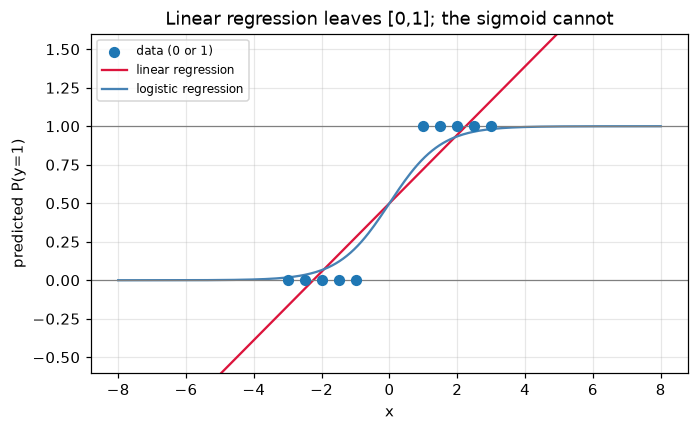

linear regression prediction at x = -8 : -1.278
linear regression prediction at x = +8 : 2.278
logistic regression at the same points : [2.40000e-05 9.99976e-01]

The linear model reports a negative probability and one above 1. Those are not
'slightly wrong' - they are outside the set of things a probability can be.


In [3]:
# One feature, a clean separation, and a linear fit on the 0/1 target.
from sklearn.linear_model import LinearRegression

x = np.array([-3.0, -2.5, -2.0, -1.5, -1.0, 1.0, 1.5, 2.0, 2.5, 3.0])
y = np.array([   0,    0,    0,    0,    0,   1,   1,   1,   1,   1])
X = x.reshape(-1, 1)

lin = LinearRegression().fit(X, y)
log = LogisticRegression().fit(X, y)

grid = np.linspace(-8, 8, 300).reshape(-1, 1)
plt.scatter(x, y, s=40, zorder=3, label="data (0 or 1)")
plt.plot(grid, lin.predict(grid), color="crimson", label="linear regression")
plt.plot(grid, log.predict_proba(grid)[:, 1], color="steelblue", label="logistic regression")
plt.axhline(0, color="gray", lw=0.8); plt.axhline(1, color="gray", lw=0.8)
plt.ylim(-0.6, 1.6); plt.xlabel("x"); plt.ylabel("predicted P(y=1)")
plt.title("Linear regression leaves [0,1]; the sigmoid cannot")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.show()

print("linear regression prediction at x = -8 :", round(lin.predict([[-8]])[0], 3))
print("linear regression prediction at x = +8 :", round(lin.predict([[8]])[0], 3))
print("logistic regression at the same points :",
      np.round(log.predict_proba([[-8], [8]])[:, 1], 6))
print()
print("The linear model reports a negative probability and one above 1. Those are not")
print("'slightly wrong' - they are outside the set of things a probability can be.")

## 1.2 The sigmoid and the log-odds

Keep the weighted sum. Rename it $z$ — the **logit**, or **log-odds**:

$$ z = w_1x_1 + w_2x_2 + \dots + w_px_p + b $$

Then squash it into $(0,1)$ with the **sigmoid** (logistic) function:

$$ p = \sigma(z) = \frac{1}{1 + e^{-z}} $$

This is not an arbitrary choice of squashing function. Invert it:

$$ z = \log\!\left(\frac{p}{1-p}\right) $$

The quantity $p/(1-p)$ is the **odds**, so $z$ is the **log-odds**. The model's real claim
is therefore:

> **The log-odds of the outcome is a linear function of the features.**

That is the whole model. "Logistic regression" is linear regression *on the log-odds scale*,
which is why it inherits linear regression's interpretability and why the coefficients mean
what they do (section 1.5).

| $z$ | odds | $p = \sigma(z)$ | reads as |
|---|---|---|---|
| $-\infty$ | 0 | 0 | certain no |
| −2 | 0.14 | 0.12 | unlikely |
| 0 | 1 | **0.5** | even money |
| +2 | 7.4 | 0.88 | likely |
| $+\infty$ | $\infty$ | 1 | certain yes |

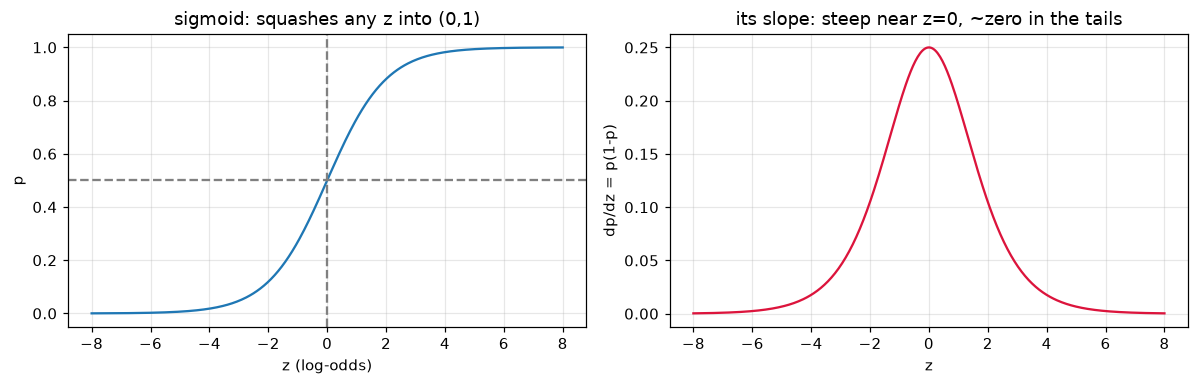

Key properties, all of which matter later:
  sigma(0)       = 0.5000      -> z=0 is the p=0.5 decision point
  sigma(-z)      = 1 - sigma(z)     -> symmetric about the origin
  d/dz sigma(z)  = sigma(z)(1-sigma(z))  -> max 0.25 at z=0, ~0 in the tails
  sigma(10)      = 0.999955   saturated

That vanishing slope in the tails is the single most important fact on this page.
It is why squared error fails (1.3) and why unseparable data can be a good thing (1.6).


In [4]:
z = np.linspace(-8, 8, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].plot(z, expit(z))
axes[0].axhline(0.5, ls="--", color="gray"); axes[0].axvline(0, ls="--", color="gray")
axes[0].set(xlabel="z (log-odds)", ylabel="p", title="sigmoid: squashes any z into (0,1)")
axes[0].grid(alpha=0.3)

# The derivative - this is what will matter in 1.3 and 1.4.
axes[1].plot(z, expit(z) * (1 - expit(z)), color="crimson")
axes[1].set(xlabel="z", ylabel="dp/dz = p(1-p)",
            title="its slope: steep near z=0, ~zero in the tails")
axes[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

print("Key properties, all of which matter later:")
print(f"  sigma(0)       = {expit(0):.4f}      -> z=0 is the p=0.5 decision point")
print(f"  sigma(-z)      = 1 - sigma(z)     -> symmetric about the origin")
print(f"  d/dz sigma(z)  = sigma(z)(1-sigma(z))  -> max {0.25} at z=0, ~0 in the tails")
print(f"  sigma(10)      = {expit(10):.6f}   saturated")
print()
print("That vanishing slope in the tails is the single most important fact on this page.")
print("It is why squared error fails (1.3) and why unseparable data can be a good thing (1.6).")

## 1.3 The loss: why not squared error?

The obvious idea is to reuse MSE: $\frac{1}{n}\sum(\sigma(z_i) - y_i)^2$. It is a genuinely
bad idea, for two separate reasons.

### Reason 1: it is not convex

Compose the sigmoid with a squared error and the resulting loss surface is **not convex in
the weights**. It *may* contain local minima and saddle points — non-convexity removes the
guarantee rather than promising trouble on every dataset — so gradient descent's answer can
depend on where it started, and you lose any assurance that the point you reached is the
global one.

We can check this rigorously rather than take it on faith: compute the Hessian and look for a
**negative eigenvalue**. A convex function has a positive semi-definite Hessian *everywhere*.

In [5]:
def numerical_hessian(theta, loss, h=1e-4):
    """Second-derivative matrix by central differences."""
    n = len(theta)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            tpp, tpm, tmp, tmm = (theta.copy() for _ in range(4))
            tpp[i] += h; tpp[j] += h
            tpm[i] += h; tpm[j] -= h
            tmp[i] -= h; tmp[j] += h
            tmm[i] -= h; tmm[j] -= h
            H[i, j] = (loss(tpp) - loss(tpm) - loss(tmp) + loss(tmm)) / (4 * h * h)
    return H


rng = np.random.default_rng(0)
Xh = np.c_[rng.normal(size=25), np.ones(25)]        # one feature + an intercept column
yh = (rng.random(25) < 0.5).astype(float)

squared_error = lambda t: np.mean((expit(Xh @ t) - yh) ** 2)
log_loss_fn   = lambda t: -np.mean(yh * np.log(expit(Xh @ t) + 1e-12)
                                   + (1 - yh) * np.log(1 - expit(Xh @ t) + 1e-12))

print(f"{'theta':<16} {'squared error eigenvalues':<32} {'log-loss eigenvalues':<28}")
print("-" * 82)
for theta in [np.array([0.1, 0.0]), np.array([4.0, 2.0]),
              np.array([6.0, -3.0]), np.array([-5.0, 4.0])]:
    e_sq = np.linalg.eigvalsh(numerical_hessian(theta, squared_error))
    e_ll = np.linalg.eigvalsh(numerical_hessian(theta, log_loss_fn))
    tag_sq = "NOT CONVEX" if e_sq.min() < -1e-6 else "ok"
    tag_ll = "NOT CONVEX" if e_ll.min() < -1e-6 else "ok"
    print(f"{str(theta.tolist()):<16} [{e_sq[0]:+.5f}, {e_sq[1]:+.5f}]  {tag_sq:<12} "
          f"[{e_ll[0]:+.5f}, {e_ll[1]:+.5f}]  {tag_ll}")

print()
print("Squared error has NEGATIVE eigenvalues at several points - proof it is not convex.")
print("Log-loss shows no negative eigenvalue anywhere we look, and can be proved positive")
print("SEMI-definite in general: its Hessian is X^T diag(p(1-p)) X, and every p(1-p) > 0,")
print("so v'Hv = sum p(1-p)(x'v)^2 >= 0 for any v. Semi-definite, note - it is positive")
print("DEFINITE only when X also has full column rank, since a v with Xv = 0 gives v'Hv = 0.")
print()
print("What convexity buys is that there are no local minima to get stuck in: every local")
print("optimum is global, so a good optimiser cannot be trapped somewhere second-rate.")
print()
print("It does NOT by itself buy a unique answer. That needs more:")
print("  - a full-rank design, or collinear columns leave a flat direction along which")
print("    many coefficient vectors score identically, and")
print("  - non-separable classes, or the maximum-likelihood optimum runs off to infinity")
print("    and no finite answer exists at all - which is section 1.6.")
print("Given both, the optimum is unique and two people fitting the same data agree.")

theta            squared error eigenvalues        log-loss eigenvalues        
----------------------------------------------------------------------------------
[0.1, 0.0]       [+0.09642, +0.13115]  ok           [+0.17845, +0.25415]  ok
[4.0, 2.0]       [-0.00714, +0.02183]  NOT CONVEX   [+0.01048, +0.12027]  ok
[6.0, -3.0]      [-0.00720, -0.00148]  NOT CONVEX   [+0.00418, +0.06387]  ok
[-5.0, 4.0]      [-0.02074, -0.00337]  NOT CONVEX   [+0.00677, +0.08903]  ok

Squared error has NEGATIVE eigenvalues at several points - proof it is not convex.
Log-loss shows no negative eigenvalue anywhere we look, and can be proved positive
SEMI-definite in general: its Hessian is X^T diag(p(1-p)) X, and every p(1-p) > 0,
so v'Hv = sum p(1-p)(x'v)^2 >= 0 for any v. Semi-definite, note - it is positive
DEFINITE only when X also has full column rank, since a v with Xv = 0 gives v'Hv = 0.

What convexity buys is that there are no local minima to get stuck in: every local
optimum is global, so a good 

### Reason 2: the gradient vanishes exactly when you need it most

Differentiate squared error through the sigmoid and you get a $\sigma'(z) = p(1-p)$ factor:

$$ \frac{\partial}{\partial z}\,(\sigma(z)-y)^2 = 2(p - y)\,p(1-p) $$

From the plot in 1.2, $p(1-p) \to 0$ in the tails. So a prediction that is **confidently
wrong** — $y=1$ while $z = -10$ — produces almost no gradient. The model has no pressure to
fix its worst mistakes.

Log-loss is designed so that factor cancels:

$$ \frac{\partial}{\partial z}\,\bigl[-y\log p - (1-y)\log(1-p)\bigr] = p - y $$

Clean, and **largest exactly when the model is most wrong**.

In [6]:
print("y = 1, but the model predicts z (very negative = confidently, badly wrong)")
print()
print(f"{'z':>5} {'p':>12} {'|grad| squared err':>20} {'|grad| log-loss':>18} {'ratio':>10}")
print("-" * 70)
for z_val in [0, -1, -3, -6, -10]:
    p = expit(z_val)
    g_sq = abs(2 * (p - 1) * p * (1 - p))
    g_ll = abs(p - 1)
    print(f"{z_val:>5} {p:>12.2e} {g_sq:>20.3e} {g_ll:>18.3e} {g_ll/g_sq if g_sq else np.inf:>10.0f}x")

print()
print("At z = -10 the model is as wrong as it is possible to be, and squared error responds")
print("with a gradient of 0.00009 - it has effectively given up. Log-loss responds with 1.0,")
print("the maximum. That factor of 11,000 is the difference between learning and not.")

y = 1, but the model predicts z (very negative = confidently, badly wrong)

    z            p   |grad| squared err    |grad| log-loss      ratio
----------------------------------------------------------------------
    0     5.00e-01            2.500e-01          5.000e-01          2x
   -1     2.69e-01            2.875e-01          7.311e-01          3x
   -3     4.74e-02            8.607e-02          9.526e-01         11x
   -6     2.47e-03            4.921e-03          9.975e-01        203x
  -10     4.54e-05            9.079e-05          1.000e+00      11014x

At z = -10 the model is as wrong as it is possible to be, and squared error responds
with a gradient of 0.00009 - it has effectively given up. Log-loss responds with 1.0,
the maximum. That factor of 11,000 is the difference between learning and not.


### Where log-loss actually comes from

It is not invented to fix the gradient — that is a happy consequence. It falls out of
**maximum likelihood**.

Each observation is a Bernoulli trial with probability $p_i$. The likelihood of seeing the
labels you actually saw is

$$ L = \prod_i p_i^{\,y_i}\,(1-p_i)^{\,1-y_i} $$

Products of many small numbers underflow, and sums are easier to differentiate, so take
logs. Maximising the log-likelihood is minimising its negative:

$$ \text{log-loss} = -\frac{1}{n}\sum_i \bigl[\, y_i \log p_i + (1-y_i)\log(1-p_i) \,\bigr] $$

Read the two terms: if $y_i = 1$ only $\log p_i$ survives, so the loss is $-\log p_i$ — zero
when $p_i=1$, and $\to\infty$ as $p_i\to 0$. **Confident and wrong is infinitely
expensive.** That is exactly the incentive you want from something producing probabilities.

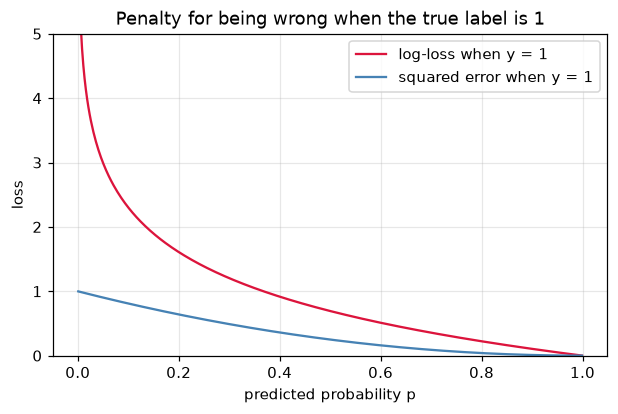

Squared error caps at 1.0 no matter how wrong you are - predicting p=0.001 when the
answer is 1 costs barely more than predicting p=0.3.
Log-loss goes to infinity. It refuses to let a model be confidently wrong cheaply.

This is also why log-loss is the right metric when you SELL the probability, and
why it punishes an uncalibrated model that accuracy and AUC would wave through.


In [7]:
p_axis = np.linspace(0.001, 0.999, 400)
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(p_axis, -np.log(p_axis), label="log-loss when y = 1", color="crimson")
ax.plot(p_axis, (p_axis - 1) ** 2, label="squared error when y = 1", color="steelblue")
ax.set(xlabel="predicted probability p", ylabel="loss",
       title="Penalty for being wrong when the true label is 1")
ax.set_ylim(0, 5); ax.legend(); ax.grid(alpha=0.3)
plt.show()

print("Squared error caps at 1.0 no matter how wrong you are - predicting p=0.001 when the")
print("answer is 1 costs barely more than predicting p=0.3.")
print("Log-loss goes to infinity. It refuses to let a model be confidently wrong cheaply.")
print()
print("This is also why log-loss is the right metric when you SELL the probability, and")
print("why it punishes an uncalibrated model that accuracy and AUC would wave through.")

## 1.4 Fitting it: there is no closed form

Linear regression has the normal equation, $w = (X^\top X)^{-1}X^\top y$ — one line of
algebra and you are done. Logistic regression **has no such formula**. Setting the gradient
to zero gives

$$ X^\top(\sigma(Xw) - y) = 0 $$

and $\sigma$ is non-linear, so $w$ cannot be isolated. You must solve it iteratively.

The good news is that the loss is convex (1.3), so any sane iterative method reaches the same
unique optimum. The gradient is beautifully simple:

$$ \nabla_w = \frac{1}{n}X^\top(p - y), \qquad \nabla_b = \frac{1}{n}\sum_i (p_i - y_i) $$

which is **identical in form to linear regression's gradient** — only the definition of $p$
changed. Twenty lines and we can fit it ourselves.

true generating   : w = [ 1.5 -2.   0.5]  b = -0.4
our gradient desc.: w = [ 1.6286 -1.6559  0.4984]  b = -0.225
sklearn (no pen.) : w = [ 1.6284 -1.6558  0.4979]  b = -0.2255

max |ours - sklearn| = 4.99e-04   <- same answer

Note we do NOT recover the true weights exactly, and that is correct: 400 samples
carry limited information. What we DO recover is sklearn's answer - the optimum of
the same logistic-regression objective, reached by a different algorithm. That is
the right thing to check here. It is not a claim that no estimator could do better
on this data; a different estimator with a different objective might.


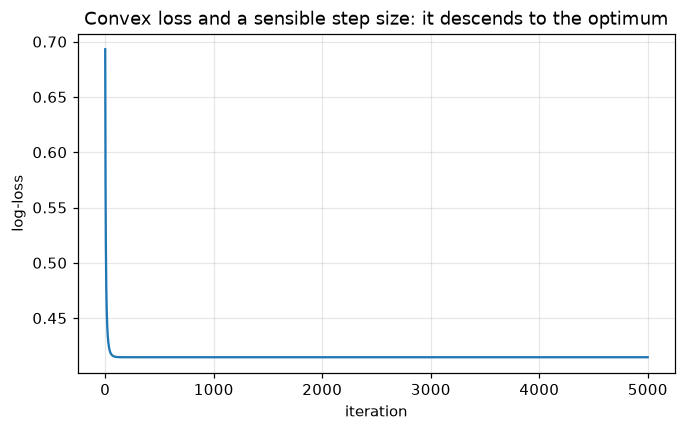

In [8]:
def fit_logistic_gd(X, y, learning_rate=0.5, iterations=5000):
    """Logistic regression by batch gradient descent. Returns (w, b, loss_history)."""
    n, p = X.shape
    w, b = np.zeros(p), 0.0
    history = []

    for _ in range(iterations):
        z = X @ w + b
        prob = expit(z)                       # forward pass
        error = prob - y                      # THE gradient signal - just (p - y)

        w -= learning_rate * (X.T @ error) / n
        b -= learning_rate * error.mean()

        history.append(-np.mean(y * np.log(prob + 1e-12)
                                + (1 - y) * np.log(1 - prob + 1e-12)))
    return w, b, history


# Data generated from a model we know, so we can check what is recovered.
rng = np.random.default_rng(1)
n_gd = 400
X_gd = rng.normal(size=(n_gd, 3))
true_w, true_b = np.array([1.5, -2.0, 0.5]), -0.4
y_gd = (rng.random(n_gd) < expit(X_gd @ true_w + true_b)).astype(int)

w_gd, b_gd, history = fit_logistic_gd(X_gd, y_gd)

# penalty=None switches sklearn's penalty off outright, so the two solve the same problem.
# (A large finite C only approximates that; prefer penalty=None when you mean "no penalty".)
sk = LogisticRegression(penalty=None, max_iter=5000).fit(X_gd, y_gd)

print("true generating   : w =", np.round(true_w, 4), " b =", true_b)
print("our gradient desc.: w =", np.round(w_gd, 4), " b =", round(b_gd, 4))
print("sklearn (no pen.) : w =", np.round(sk.coef_[0], 4), " b =", round(sk.intercept_[0], 4))
print(f"\nmax |ours - sklearn| = {np.abs(w_gd - sk.coef_[0]).max():.2e}   <- same answer")
print()
print("Note we do NOT recover the true weights exactly, and that is correct: 400 samples")
print("carry limited information. What we DO recover is sklearn's answer - the optimum of")
print("the same logistic-regression objective, reached by a different algorithm. That is")
print("the right thing to check here. It is not a claim that no estimator could do better")
print("on this data; a different estimator with a different objective might.")

plt.plot(history)
plt.xlabel("iteration"); plt.ylabel("log-loss")
plt.title("Convex loss and a sensible step size: it descends to the optimum")
plt.grid(alpha=0.3); plt.show()

### What sklearn actually uses

Gradient descent is the clearest way to *see* it, not the fastest way to *do* it. sklearn
offers several solvers, and the default is worth understanding:

| `solver` | Method | Use when |
|---|---|---|
| `"lbfgs"` (default) | Quasi-Newton, approximates the Hessian | Default. Good on small/medium dense data. |
| `"liblinear"` | Coordinate descent | Small data; the only one supporting pure L1 with `penalty="l1"` historically |
| `"newton-cholesky"` | Exact Newton | `n_samples >> n_features`, dense |
| `"saga"` | Stochastic average gradient | **Large** data; supports L1 and elasticnet |
| `SGDClassifier(loss="log_loss")` | Plain SGD | Data that does not fit in memory; `partial_fit` streaming |

Newton-type methods use the second derivative, so they need far fewer iterations than plain
gradient descent — which is why `lbfgs` converges in tens of steps where ours took thousands.

If you see `ConvergenceWarning: lbfgs failed to converge`, **scaling your features is the
first thing to check** — badly scaled inputs are the most common cause — and raising
`max_iter` the second. They are not the only causes, though: near-separable classes (§1.6),
severe collinearity, and a solver that does not suit the penalty will all produce the same
warning, and none of them is fixed by more iterations.

## 1.5 Reading the coefficients: odds ratios

This is the reason the model survives in regulated industries, and it is the part people get
wrong most often.

Because $z$ is the log-odds and $z$ is linear in the features:

$$ \text{odds} = e^{z} = e^{b}\cdot e^{w_1x_1}\cdot e^{w_2x_2}\cdots $$

Increase $x_i$ by one unit **while holding every other feature in the model fixed**, and $z$
rises by $w_i$, so the **odds get multiplied by $e^{w_i}$**. That multiplier is the **odds
ratio**.

The italicised condition is not a formality. $e^{w_i}$ is a *partial* effect — it describes a
comparison between two rows identical in every other modelled feature. It is also specific to
a model with no interaction involving $x_i$: add one, and the odds ratio for $x_i$ depends on
the value of whatever it interacts with, and a single number no longer describes it.

| $w_i$ | $e^{w_i}$ | Plain English |
|---|---|---|
| +0.69 | 2.0 | doubles the odds |
| +0.10 | 1.11 | +11% odds |
| 0 | 1.0 | no effect |
| −0.69 | 0.5 | halves the odds |
| −1.61 | 0.2 | cuts odds to a fifth |

**Three things that trip people up:**

1. **It is odds, not probability.** Doubling the odds of something rare roughly doubles its
   probability; doubling the odds of something already at $p=0.8$ takes it only to $0.89$.
2. **The odds ratio is constant, the probability effect is not.** The same $w_i$ moves
   probability most near $p=0.5$ and barely at all near 0 or 1 — that is the sigmoid's
   vanishing slope again.
3. **Scaled features change the units.** After `StandardScaler`, "one unit" means "one
   standard deviation", so the coefficient is per-SD, not per-original-unit.

In [9]:
# Recover known odds ratios from data generated with them.
rng = np.random.default_rng(7)
n_or = 4000
tenure = rng.normal(0, 1, n_or)          # already standardised, for clean interpretation
price  = rng.normal(0, 1, n_or)
noise  = rng.normal(0, 1, n_or)          # a planted null: true coefficient is exactly 0

TRUE = {"tenure": -0.7, "price": 0.4, "noise": 0.0}
z_true = -2.0 + TRUE["tenure"] * tenure + TRUE["price"] * price
y_or = (rng.random(n_or) < expit(z_true)).astype(int)

X_or = pd.DataFrame({"tenure": tenure, "price": price, "noise": noise})
m_or = LogisticRegression(penalty=None, max_iter=2000).fit(X_or, y_or)

print(f"base rate: {y_or.mean():.3f}\n")
print(f"{'feature':<10} {'true w':>8} {'fitted w':>10} {'odds ratio':>12}  interpretation")
print("-" * 82)
for name, w in zip(X_or.columns, m_or.coef_[0]):
    odds_ratio = np.exp(w)
    pct = (odds_ratio - 1) * 100
    direction = "raises" if pct > 0 else "lowers"
    print(f"{name:<10} {TRUE[name]:>8.2f} {w:>10.4f} {odds_ratio:>12.4f}  "
          f"+1 SD {direction} the odds by {abs(pct):.0f}%")
print(f"\nintercept {m_or.intercept_[0]:.4f} -> baseline odds {np.exp(m_or.intercept_[0]):.4f}"
      f" -> p = {expit(m_or.intercept_[0]):.4f} when every feature is at its mean")

base rate: 0.135

feature      true w   fitted w   odds ratio  interpretation
----------------------------------------------------------------------------------
tenure        -0.70    -0.7695       0.4632  +1 SD lowers the odds by 54%
price          0.40     0.3519       1.4218  +1 SD raises the odds by 42%
noise          0.00    -0.0086       0.9915  +1 SD lowers the odds by 1%

intercept -2.1003 -> baseline odds 0.1224 -> p = 0.1091 when every feature is at its mean


In [10]:
# Point 2 above, made concrete: the SAME coefficient moves probability by wildly
# different amounts depending on where you start.
w = 0.7                                   # odds ratio e^0.7 = 2.01, i.e. "doubles the odds"
print(f"a coefficient of {w} (odds ratio {np.exp(w):.2f}, 'roughly doubles the odds')\n")
print(f"{'starting p':>11} {'starting odds':>14} {'new odds':>10} {'new p':>8} {'change in p':>13}")
print("-" * 62)
for p0 in [0.01, 0.05, 0.2, 0.5, 0.8, 0.95]:
    odds0 = p0 / (1 - p0)
    odds1 = odds0 * np.exp(w)
    p1 = odds1 / (1 + odds1)
    print(f"{p0:>11.2f} {odds0:>14.3f} {odds1:>10.3f} {p1:>8.3f} {p1-p0:>+13.3f}")

print()
print("Same coefficient, same odds ratio, every row. But the probability moves +0.17 in the")
print("middle and only +0.01 at the bottom and +0.03 at the top. If a stakeholder hears")
print("'doubles the risk' they picture the middle row. Quote the probability change at")
print("THEIR operating point, not the odds ratio, unless they genuinely think in odds.")

a coefficient of 0.7 (odds ratio 2.01, 'roughly doubles the odds')

 starting p  starting odds   new odds    new p   change in p
--------------------------------------------------------------
       0.01          0.010      0.020    0.020        +0.010
       0.05          0.053      0.106    0.096        +0.046
       0.20          0.250      0.503    0.335        +0.135
       0.50          1.000      2.014    0.668        +0.168
       0.80          4.000      8.055    0.890        +0.090
       0.95         19.000     38.261    0.975        +0.025

Same coefficient, same odds ratio, every row. But the probability moves +0.17 in the
middle and only +0.01 at the bottom and +0.03 at the top. If a stakeholder hears
'doubles the risk' they picture the middle row. Quote the probability change at
THEIR operating point, not the odds ratio, unless they genuinely think in odds.


## 1.6 Regularization, and sklearn's confusing `C`

**sklearn regularizes by default.** `LogisticRegression()` applies L2 with `C=1.0` unless you
say otherwise — unlike `LinearRegression()`, which applies none. This surprises people, and
it is why our from-scratch comparison in 1.4 had to switch the penalty off. Use
`penalty=None` when you mean "no penalty" — a large finite `C` such as `1e6` only
approximates one, and is worth keeping only for a solver that will not accept `None`.

The penalised objective is

$$ \min_w \; C \sum_i \bigl[\text{log-loss}_i\bigr] + \tfrac{1}{2}\lVert w\rVert^2 $$

so **`C` multiplies the data term, not the penalty**:

> ### `C` is *inverse* regularization strength. Small `C` = strong penalty.

This is backwards from `alpha` in `Ridge`/`Lasso`, and mixing them up is a classic bug.

| | Ridge / Lasso | LogisticRegression |
|---|---|---|
| Parameter | `alpha` | `C` |
| Stronger penalty | **larger** alpha | **smaller** C |
| No penalty | `alpha=0` | `C=` huge (`1e6`) |
| Relationship | — | $C \approx 1/\alpha$ |

In [11]:
print("C sweep on the same data - watch the coefficients shrink as C DECREASES")
print(f"\n{'C':>10} {'|w1|':>8} {'|w2|':>8} {'|w3|':>8}   effect")
print("-" * 56)
for C in [0.001, 0.01, 0.1, 1.0, 100.0]:
    m = LogisticRegression(C=C, max_iter=5000).fit(X_gd, y_gd)
    a = np.abs(m.coef_[0])
    note = "crushed to ~0" if C <= 0.001 else ("sklearn default" if C == 1.0 else
           ("essentially unpenalised" if C >= 100 else ""))
    print(f"{C:>10} {a[0]:>8.3f} {a[1]:>8.3f} {a[2]:>8.3f}   {note}")

print(f"\ntrue weights: {np.abs(true_w)}")
print()
print("Tune C on a LOG scale, exactly like alpha: np.logspace(-4, 4, 20).")
print("LogisticRegressionCV does it for you with an efficient warm-started path.")

C sweep on the same data - watch the coefficients shrink as C DECREASES

         C     |w1|     |w2|     |w3|   effect
--------------------------------------------------------
     0.001    0.081    0.081    0.029   crushed to ~0
      0.01    0.466    0.470    0.158   
       0.1    1.151    1.165    0.362   
       1.0    1.546    1.570    0.475   sklearn default
     100.0    1.627    1.655    0.498   essentially unpenalised

true weights: [1.5 2.  0.5]

Tune C on a LOG scale, exactly like alpha: np.logspace(-4, 4, 20).
LogisticRegressionCV does it for you with an efficient warm-started path.


### Penalties and separable data

| `penalty` | Effect | Solver support |
|---|---|---|
| `"l2"` (default) | Shrinks all coefficients | all |
| `"l1"` | Shrinks and **zeroes** some — feature selection | `liblinear`, `saga` |
| `"elasticnet"` | Mix, via `l1_ratio` | `saga` only |
| `None` | No penalty | all except `liblinear` |

There is a second, less obvious reason regularization matters here. If your classes are
**perfectly separable**, the unpenalised maximum-likelihood solution *does not exist*: the
model can always lower its loss by scaling all the weights up, pushing predictions towards
0 and 1, so the weights run off to infinity. Any non-zero L2 penalty makes the problem
well-posed again.

This is the direct analogue of ridge fixing a singular $X^\top X$ in linear regression — and
it is why sklearn regularizes by default rather than leaving you to discover the failure.

In [12]:
# Perfectly separable data: everything below 0 is class 0, everything above is class 1.
X_sep = np.array([[-3.], [-2.], [-1.], [1.], [2.], [3.]])
y_sep = np.array([0, 0, 0, 1, 1, 1])

print(f"{'C':>10} {'coefficient':>13}   what is happening")
print("-" * 60)
for C in [0.01, 1.0, 100.0, 10_000.0, 1_000_000.0]:
    m = LogisticRegression(C=C, max_iter=10_000).fit(X_sep, y_sep)
    print(f"{C:>10} {m.coef_[0][0]:>13.3f}   {'running away ->' if C >= 100 else 'held in check'}")

print()
print("The coefficient grows without bound as the penalty weakens. There is no finite")
print("maximum-likelihood answer here - the likelihood keeps improving as w -> infinity.")
print()
print("In practice you meet this as: a suspiciously huge coefficient, a ConvergenceWarning,")
print("or perfect training accuracy. Leakage - a feature that is a proxy for the label - is")
print("the first thing to check, and often the answer (Foundations Part 3.2).")
print()
print("But separation is not always a bug. It happens genuinely with small samples, sparse")
print("categories where one level has no positives at all, high-dimensional data where")
print("p approaches n, and occasionally a real deterministic rule. If you have ruled out")
print("leakage, a penalty - or Firth's bias-reduced logistic regression - is the fix, not a")
print("workaround.")

         C   coefficient   what is happening
------------------------------------------------------------
      0.01         0.056   held in check
       1.0         1.104   held in check
     100.0         3.938   running away ->
   10000.0         7.623   running away ->
 1000000.0         8.337   running away ->

The coefficient grows without bound as the penalty weakens. There is no finite
maximum-likelihood answer here - the likelihood keeps improving as w -> infinity.

In practice you meet this as: a suspiciously huge coefficient, a ConvergenceWarning,
or perfect training accuracy. Leakage - a feature that is a proxy for the label - is
the first thing to check, and often the answer (Foundations Part 3.2).

But separation is not always a bug. It happens genuinely with small samples, sparse
categories where one level has no positives at all, high-dimensional data where
p approaches n, and occasionally a real deterministic rule. If you have ruled out
leakage, a penalty - or Firth's 

## 1.7 More than two classes

Two ways to generalise, and sklearn picks the second for you.

**One-vs-Rest (OvR).** Train $K$ independent binary classifiers, "class $k$ vs everything
else". Predict with whichever is most confident. Simple, parallel, but the $K$ probabilities
are produced independently and **do not sum to 1** without renormalising.

**Multinomial (softmax).** One joint model with a weight vector per class, trained on a
single loss:

$$ P(y=k \mid x) = \frac{e^{z_k}}{\sum_{j} e^{z_j}}, \qquad z_k = w_k^\top x + b_k $$

The probabilities sum to 1 **by construction**, and the classes compete during training,
which is usually what you want. This is the default, and it is exactly the softmax layer that
ends most neural network classifiers.

In [13]:
X_wine, y_wine = load_wine(return_X_y=True)

multinomial = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
one_vs_rest = make_pipeline(StandardScaler(),
                            OneVsRestClassifier(LogisticRegression(max_iter=5000)))

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
print(f"wine: {X_wine.shape[0]} samples, {X_wine.shape[1]} features, "
      f"{len(np.unique(y_wine))} classes")
print(f"  multinomial (softmax, default) CV accuracy: "
      f"{cross_val_score(multinomial, X_wine, y_wine, cv=cv).mean():.4f}")
print(f"  one-vs-rest (3 binary models)  CV accuracy: "
      f"{cross_val_score(one_vs_rest, X_wine, y_wine, cv=cv).mean():.4f}")

fitted = multinomial.fit(X_wine, y_wine)
print(f"\ncoef_ shape: {fitted[-1].coef_.shape}  -> one row of weights per class")
print("softmax probabilities sum to:",
      np.round(fitted.predict_proba(X_wine[:3]).sum(axis=1), 10).tolist())

# What the individual OvR binary models say BEFORE sklearn renormalises them.
ovr_fitted = one_vs_rest.fit(X_wine, y_wine)
scaled = ovr_fitted[0].transform(X_wine[:3])
raw = np.column_stack([est.predict_proba(scaled)[:, 1]
                       for est in ovr_fitted[-1].estimators_])
print("\nOvR, raw per-class probabilities (each binary model asked separately):")
print(np.round(raw, 4))
print("their row sums:", np.round(raw.sum(axis=1), 4).tolist(), " <- NOT 1")
print("after sklearn renormalises:",
      np.round(ovr_fitted.predict_proba(X_wine[:3]).sum(axis=1), 4).tolist())
print()
print("That is the structural difference. Softmax probabilities sum to 1 BY CONSTRUCTION,")
print("because the classes share one loss and compete during training. OvR trains each")
print("model in ignorance of the others, so its outputs need rescaling afterwards - which")
print("sklearn does for you, quietly.")
print()
print("Accuracy is near-identical on this small, easy dataset - which is one data point,")
print("not a general result; the gap between the two grows on harder problems and with")
print("more classes. Prefer multinomial for structural reasons rather than measured ones:")
print("one model instead of K, and probabilities that sum to 1 by construction.")
print()
print("Reach for OvR when you need per-class models you can inspect or retrain separately,")
print("or for multi-LABEL problems where a sample can belong to several classes at once -")
print("softmax cannot express that, because its outputs are forced to sum to 1.")

wine: 178 samples, 13 features, 3 classes
  multinomial (softmax, default) CV accuracy: 0.9833


  one-vs-rest (3 binary models)  CV accuracy: 0.9833

coef_ shape: (3, 13)  -> one row of weights per class
softmax probabilities sum to: [1.0, 1.0, 1.0]

OvR, raw per-class probabilities (each binary model asked separately):
[[9.994e-01 1.800e-03 4.000e-04]
 [9.949e-01 3.310e-02 3.000e-04]
 [9.898e-01 5.300e-03 6.000e-04]]
their row sums: [1.0016, 1.0282, 0.9957]  <- NOT 1
after sklearn renormalises: [1.0, 1.0, 1.0]

That is the structural difference. Softmax probabilities sum to 1 BY CONSTRUCTION,
because the classes share one loss and compete during training. OvR trains each
model in ignorance of the others, so its outputs need rescaling afterwards - which
sklearn does for you, quietly.

Accuracy is near-identical on this small, easy dataset - which is one data point,
not a general result; the gap between the two grows on harder problems and with
more classes. Prefer multinomial for structural reasons rather than measured ones:
one model instead of K, and probabilities that sum to 1

***
# Part 2 - Worked example: customer churn

We now run the full Foundations workflow on an imbalanced, mixed-type problem. The steps
themselves (split → baseline → pipeline → validate → diagnose → test once) are covered in
[Foundations Part 1](ml_foundations_zero_to_hero.ipynb); here we focus on what is
**specific to logistic regression** — the probability output, the odds ratios, and what
imbalance does to all of it.

**The problem.** Predict which customers will churn in the next quarter, so a retention team
can call them. About 7% churn, which makes accuracy alone insufficient — and actively
misleading — from the start: a model that predicts "nobody churns" is 93% accurate.

The data is synthetic and generated from **known coefficients**, so we can check what the
model recovers — something a real dataset can never give you.

In [14]:
def make_churn_data(n=6000, seed=RANDOM_STATE):
    """Synthetic telco-style churn. TRUE log-odds:

        z = -2.9  - 0.030*tenure_months
                  + 0.016*monthly_charges
                  + 0.350*support_calls
                  + contract effect (month-to-month 0, one_year -1.0, two_year -1.8)
                  + 0.0  *age                 <- a planted null

    `age` and `paperless_billing` have NO real effect. We will see what the model says
    about them, which is the honest way to calibrate your trust in the other coefficients.
    """
    rng = np.random.default_rng(seed)

    tenure_months = rng.integers(1, 73, n).astype(float)
    monthly_charges = rng.normal(70, 25, n).clip(20, 150)
    age = rng.integers(18, 80, n).astype(float)
    support_calls = rng.poisson(1.2, n).astype(float)
    contract = rng.choice(["month-to-month", "one_year", "two_year"], n, p=[.55, .25, .20])
    paperless_billing = rng.choice(["yes", "no"], n, p=[.6, .4])

    contract_effect = pd.Series(contract).map(
        {"month-to-month": 0.0, "one_year": -1.0, "two_year": -1.8}).to_numpy()

    z = (-2.9 - 0.030 * tenure_months + 0.016 * monthly_charges
         + 0.35 * support_calls + contract_effect)
    churn = (rng.random(n) < expit(z)).astype(int)

    return pd.DataFrame({
        "tenure_months": tenure_months, "monthly_charges": monthly_charges,
        "age": age, "support_calls": support_calls, "contract": contract,
        "paperless_billing": paperless_billing, "churn": churn,
    })


churn_df = make_churn_data()
print(churn_df.head(6).to_string())
print()
print(churn_df.dtypes.to_string())
print(f"\nrows {len(churn_df)}   missing {churn_df.isna().sum().sum()}   "
      f"duplicated {churn_df.duplicated().sum()}")
print(f"churn rate {churn_df['churn'].mean():.3%}   ({churn_df['churn'].sum()} churners)")
print()
print("That is the whole of step 1, and it is deliberately target-BLIND apart from the")
print("marginal churn rate - which we need in order to know the problem is imbalanced and")
print("that the split has to be stratified. Anything that pairs a FEATURE against churn -")
print("'which contract types churn most' - waits until after the split, because every such")
print("observation is a modelling decision in waiting.")

   tenure_months  monthly_charges   age  support_calls        contract paperless_billing  churn
0            7.0        96.409640  51.0            1.0  month-to-month                no      0
1           56.0        51.119515  21.0            2.0        one_year               yes      0
2           48.0        20.000000  79.0            1.0  month-to-month                no      0
3           32.0        25.825953  62.0            3.0        one_year                no      0
4           32.0       105.540674  46.0            0.0        two_year                no      0
5           62.0        59.968627  32.0            2.0        one_year               yes      0

tenure_months        float64
monthly_charges      float64
age                  float64
support_calls        float64
contract                 str
paperless_billing        str
churn                  int64

rows 6000   missing 0   duplicated 2
churn rate 7.233%   (434 churners)

That is the whole of step 1, and it is deliberatel

In [15]:
X = churn_df.drop(columns="churn")
y = churn_df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE   # stratify: rare class
)

# A second split, immediately. Everything between here and 3.3 is either an inspection
# or a decision - the diagnostics, the threshold sweep, the class-weight experiment, the
# calibration curves - and all of it belongs on validation data. The test set is not
# opened again until 3.3.
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=RANDOM_STATE
)

print(f"fit {len(X_fit)}   validation {len(X_val)}   test {len(X_test)}")
print(f"churn rate  fit {y_fit.mean():.4f}   val {y_val.mean():.4f}   <- stratify worked")
print(f"test: {len(X_test)} rows, sealed until 3.3 - and note we do not print its churn")
print("rate either, because 'does my test set look representative?' is a question you")
print("would act on, and acting on it means re-drawing the split until it looks agreeable.")

# The baseline, measured the way every candidate will be: CV on the training data.
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
dummy = DummyClassifier(strategy="most_frequent")
d_acc = cross_val_score(dummy, X_train, y_train, cv=cv, scoring="accuracy")
d_auc = cross_val_score(dummy, X_train, y_train, cv=cv, scoring="roc_auc")

print(f"\nbaseline (always predict 'no churn'), 5-fold CV on training data:")
print(f"  accuracy {d_acc.mean():.4f}   ROC-AUC {d_auc.mean():.4f}")
print(f"  {d_acc.mean():.0%} accurate while catching zero churners. On a {y_train.mean():.0%}")
print("  problem accuracy alone is not enough to tell a useful model from a useless one -")
print("  it is not that accuracy is meaningless, it is that it cannot see the rare class.")

fit 3375   validation 1125   test 1500
churn rate  fit 0.0726   val 0.0720   <- stratify worked
test: 1500 rows, sealed until 3.3 - and note we do not print its churn
rate either, because 'does my test set look representative?' is a question you
would act on, and acting on it means re-drawing the split until it looks agreeable.

baseline (always predict 'no churn'), 5-fold CV on training data:
  accuracy 0.9276   ROC-AUC 0.5000
  93% accurate while catching zero churners. On a 7%
  problem accuracy alone is not enough to tell a useful model from a useless one -
  it is not that accuracy is meaningless, it is that it cannot see the rare class.


### Target-aware EDA — training data only

Now the part that pairs features against the outcome. Everything below is computed from the
training rows, so nothing here can be contaminated by the validation or test sets.

In [16]:
numeric_features = ["tenure_months", "monthly_charges", "age", "support_calls"]
categorical_features = ["contract", "paperless_billing"]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])

# penalty=None asks for a genuinely unpenalised fit - the honest maximum-likelihood
# estimates, which is what we want when the GOAL is interpretation. (A large finite C
# only approximates this; sklearn supports switching the penalty off outright, so say so.)
# Part 3 uses a tuned C.
def churn_pipeline(**kw):
    return Pipeline([("prep", preprocess),
                     ("model", LogisticRegression(max_iter=2000, penalty=None, **kw))])


# Fitted on all the training data: this is the model whose COEFFICIENTS we read in 2.1.
churn_model = churn_pipeline().fit(X_train, y_train)

# Fitted on the fit-half only, so its validation predictions are honest. Every diagnostic
# and every threshold decision between here and 3.3 uses this one.
fit_model = churn_pipeline().fit(X_fit, y_fit)
val_proba = fit_model.predict_proba(X_val)[:, 1]

scores = cross_validate(churn_model, X_train, y_train, cv=cv,
                        scoring=["roc_auc", "average_precision", "neg_log_loss", "f1"])
print("cross-validated on the TRAINING data only:")
print(f"  ROC-AUC          {scores['test_roc_auc'].mean():.4f} "
      f"(+/- {scores['test_roc_auc'].std():.4f})")
print(f"  AP               {scores['test_average_precision'].mean():.4f} "
      f"(+/- {scores['test_average_precision'].std():.4f})   base rate {y_train.mean():.4f}")
print(f"  log-loss         {-scores['test_neg_log_loss'].mean():.4f}")
print(f"  F1 (at p>=0.5)   {scores['test_f1'].mean():.4f}   <- see Part 3 before believing this")

cross-validated on the TRAINING data only:
  ROC-AUC          0.7490 (+/- 0.0238)
  AP               0.1934 (+/- 0.0364)   base rate 0.0724
  log-loss         0.2330
  F1 (at p>=0.5)   0.0000   <- see Part 3 before believing this


In [17]:
train_df = X_train.copy()
train_df["churn"] = y_train

print("churn rate by contract type (TRAINING data):")
print(train_df.groupby("contract")["churn"].agg(["mean", "count"]).round(4).to_string())
print()
print("Month-to-month customers churn far more - which we would expect, and which the")
print("model had better reproduce. Checking it here rather than before the split costs")
print("nothing: with 4,500 training rows the pattern is just as visible.")
print()
print("churn rate by paperless billing (a planted null):")
print(train_df.groupby("paperless_billing")["churn"].agg(["mean", "count"]).round(4).to_string())
print("Close together, as it should be - we generated this column with no effect at all.")

churn rate by contract type (TRAINING data):
                  mean  count
contract                     
month-to-month  0.1088   2454
one_year        0.0369   1138
two_year        0.0187    908

Month-to-month customers churn far more - which we would expect, and which the
model had better reproduce. Checking it here rather than before the split costs
nothing: with 4,500 training rows the pattern is just as visible.

churn rate by paperless billing (a planted null):
                     mean  count
paperless_billing               
no                 0.0743   1776
yes                0.0712   2724
Close together, as it should be - we generated this column with no effect at all.


## 2.1 Reading the coefficients — the part you present

This is what logistic regression is *for*. Two views of the same model:

- **odds ratio per natural unit** — "per extra month of tenure" — for talking to the business
- **odds ratio per standard deviation** — a scale-adjusted effect size, so the *numeric*
  coefficients can be compared with each other at all

That second one is not a feature-importance measure, and it is worth being clear why. It is
comparable only among the standardised numeric columns — the one-hot categorical columns here
are not standardised, so their coefficients are on a different footing entirely. It is a
*partial* effect, so with correlated predictors a large value can be half of a near-cancelling
pair rather than a real effect (`s1`/`s2` in the linear-regression notebook is the worked
example of this). And it describes the fitted model, not predictive value: for "which feature
is the model actually relying on", use validation-based permutation importance.

In [18]:
feature_names = churn_model["prep"].get_feature_names_out()
std_coefs = churn_model["model"].coef_[0]
num_scale = churn_model["prep"].named_transformers_["num"].scale_

# Undo the scaling for the numeric block to get coefficients in natural units.
raw_coefs = std_coefs.copy()
raw_coefs[:len(num_scale)] = std_coefs[:len(num_scale)] / num_scale

TRUE_COEFS = {
    "tenure_months": -0.030, "monthly_charges": 0.016, "age": 0.0,
    "support_calls": 0.35, "contract_one_year": -1.0, "contract_two_year": -1.8,
    "paperless_billing_yes": 0.0,
}

rows = []
for name, raw, std in zip(feature_names, raw_coefs, std_coefs):
    key = name.split("__")[1]
    rows.append({
        "feature": key,
        "true_w": TRUE_COEFS.get(key, np.nan),
        "fitted_w": raw,
        "odds_ratio": np.exp(raw),
        "OR_per_SD": np.exp(std),
    })
table = pd.DataFrame(rows)
print(table.to_string(index=False, float_format=lambda v: f"{v:9.4f}"))
print(f"\nintercept {churn_model['model'].intercept_[0]:.4f}")
print()
print("The model recovers every planted effect: the signs are all right and the magnitudes")
print("are close, with the contract effects slightly overshot.")
print()
print("Now look at the two features whose true coefficient is EXACTLY ZERO.")
print(f"  age                   -> odds ratio {table.set_index('feature').loc['age','odds_ratio']:.3f}"
      "  (reads as ~0% effect - correct)")
print(f"  paperless_billing_yes -> odds ratio "
      f"{table.set_index('feature').loc['paperless_billing_yes','odds_ratio']:.3f}"
      "  (reads as an 11% REDUCTION in odds)")
print()
print("The second one is pure noise, and yet it looks like a finding. If this were real")
print("data you would have no way to know, and someone would put 'paperless billing")
print("reduces churn 11%' on a slide.")
print()
print("What that establishes is qualitative, and it is the important part: a variable")
print("with NO effect at all can still come back looking like a finding, purely from")
print("sampling noise.")
print()
print("What it does NOT establish is a numeric noise band. This is one draw of one null")
print("feature; reading 'anything inside 0.89-1.12 is noise' off it would be over-reading")
print("a single sample, and the width of that interval would change with the sample size,")
print("the feature's variance, and the next random seed.")
print()
print("For an interval you can actually defend, use the standard errors - statsmodels'")
print("Logit().fit().summary() gives them directly - or bootstrap the coefficient, or")
print("simulate many null features and look at the spread of what comes back. Any")
print("coefficient you intend to act on needs to clear that, not a number read off one")
print("example.")

              feature    true_w  fitted_w  odds_ratio  OR_per_SD
        tenure_months   -0.0300   -0.0253      0.9750     0.5912
      monthly_charges    0.0160    0.0134      1.0135     1.3843
                  age    0.0000   -0.0012      0.9988     0.9791
        support_calls    0.3500    0.3279      1.3881     1.4371
    contract_one_year   -1.0000   -1.1796      0.3074     0.3074
    contract_two_year   -1.8000   -1.8952      0.1503     0.1503
paperless_billing_yes    0.0000   -0.1178      0.8889     0.8889

intercept -2.2369

The model recovers every planted effect: the signs are all right and the magnitudes
are close, with the contract effects slightly overshot.

Now look at the two features whose true coefficient is EXACTLY ZERO.
  age                   -> odds ratio 0.999  (reads as ~0% effect - correct)
  paperless_billing_yes -> odds ratio 0.889  (reads as an 11% REDUCTION in odds)

The second one is pure noise, and yet it looks like a finding. If this were real
data you w

In [19]:
# The same numbers, as sentences you could put in a slide.
print("WHAT THE MODEL SAYS ABOUT CHURN\n")
lookup = table.set_index("feature")

def sentence(feature, unit, direction_word="raises"):
    orr = lookup.loc[feature, "odds_ratio"]
    pct = (orr - 1) * 100
    verb = "raises" if pct > 0 else "lowers"
    return f"  {unit:<34} {verb} the odds of churn by {abs(pct):5.1f}%   (OR {orr:.3f})"

print(sentence("support_calls", "each extra support call"))
print(sentence("monthly_charges", "each extra $1 on the monthly bill"))
print(sentence("tenure_months", "each extra month of tenure"))
print(sentence("contract_one_year", "a 1-year contract (vs month-to-month)"))
print(sentence("contract_two_year", "a 2-year contract (vs month-to-month)"))
print()
or_calls = lookup.loc["support_calls", "odds_ratio"]
print("Odds ratios MULTIPLY across units - raise them to a power, never multiply the")
print("percentage. The error is invisible for small effects and large for big ones:")
print(f"  3 support calls: {or_calls:.3f}^3 = {or_calls**3:.2f}x the odds "
      f"(+{(or_calls**3-1)*100:.0f}%), NOT 3 x {(or_calls-1)*100:.0f}% = "
      f"{3*(or_calls-1)*100:.0f}%")
print(f"  a year of tenure: {lookup.loc['tenure_months','odds_ratio']:.4f}^12 = "
      f"{lookup.loc['tenure_months','odds_ratio']**12:.3f}x the odds")
print()
print("CAUTION 1: 'raises the odds' is not 'raises the probability by the same amount'.")
print("           See 1.5 - the probability effect depends on where the customer starts.")
print("CAUTION 2: this is observational data. Nobody randomised customers into contracts,")
print("           so 'two-year contracts reduce churn' may be selection: loyal customers")
print("           choose long contracts. The model cannot tell those apart.")

WHAT THE MODEL SAYS ABOUT CHURN

  each extra support call            raises the odds of churn by  38.8%   (OR 1.388)
  each extra $1 on the monthly bill  raises the odds of churn by   1.4%   (OR 1.014)
  each extra month of tenure         lowers the odds of churn by   2.5%   (OR 0.975)
  a 1-year contract (vs month-to-month) lowers the odds of churn by  69.3%   (OR 0.307)
  a 2-year contract (vs month-to-month) lowers the odds of churn by  85.0%   (OR 0.150)

Odds ratios MULTIPLY across units - raise them to a power, never multiply the
percentage. The error is invisible for small effects and large for big ones:
  3 support calls: 1.388^3 = 2.67x the odds (+167%), NOT 3 x 39% = 116%
  a year of tenure: 0.9750^12 = 0.738x the odds

CAUTION 1: 'raises the odds' is not 'raises the probability by the same amount'.
           See 1.5 - the probability effect depends on where the customer starts.
CAUTION 2: this is observational data. Nobody randomised customers into contracts,
           so

## 2.2 Diagnosing a classifier

The OLS residuals-vs-fitted plot does not transfer directly — residuals of a 0/1 target
against a fitted probability fall on two curves and are awkward to read. Logistic regression
has its own diagnostics for the same job (deviance and Pearson residuals, leverage, Cook's
distance, and binned residual plots), and `statsmodels` exposes them.

What follows is the practical pair that catches most problems: the confusion matrix at your
operating threshold, and the rows the model gets most confidently wrong.

In [20]:
# Validation, not test. Same lesson, honest data.
val_pred = fit_model.predict(X_val)

tn, fp, fn, tp = confusion_matrix(y_val, val_pred).ravel()
print("at the DEFAULT threshold of 0.5")
print(f"                  predicted stay   predicted churn")
print(f"  actually stay   {tn:>14}   {fp:>15}")
print(f"  actually churn  {fn:>14}   {tp:>15}   <- we caught {tp} of {tp+fn}")
print()
print(f"  accuracy  {accuracy_score(y_val, val_pred):.4f}  (baseline {1-y_val.mean():.4f})")
print(f"  precision {precision_score(y_val, val_pred, zero_division=0):.4f}")
print(f"  recall    {recall_score(y_val, val_pred):.4f}   <- the number that matters here")
print(f"  ROC-AUC   {roc_auc_score(y_val, val_proba):.4f}")
print(f"  AP        {average_precision_score(y_val, val_proba):.4f}  (base rate {y_val.mean():.4f})")
print()
print(f"Read that confusion matrix again: the model flagged {tp + fp} customers in total and")
print(f"caught {tp} of the {tp + fn} churners. Its accuracy exactly equals the do-nothing")
print("baseline, because it IS the do-nothing baseline at this threshold.")
print()
print(f"And yet its AUC is {roc_auc_score(y_val, val_proba):.2f} - the ranking carries real")
print("information. Before blaming the model, look at the operating threshold: a useful")
print("ranking scored at a badly chosen cut-off is exactly what this looks like. That is")
print("all of Part 3. (Ranking is not the only thing that can be wrong - calibration can")
print("be too, which is 3.2 - but the threshold is the cheapest thing to check first.)")
print()
print("Why this happens is worth internalising: a CALIBRATED model on a 7% problem should")
print("rarely output above 0.5, because a customer with a >50% chance of churning barely")
print("exists in this data. Demanding p >= 0.5 is demanding near-certainty.")

at the DEFAULT threshold of 0.5
                  predicted stay   predicted churn
  actually stay             1044                 0
  actually churn              81                 0   <- we caught 0 of 81

  accuracy  0.9280  (baseline 0.9280)
  precision 0.0000
  recall    0.0000   <- the number that matters here
  ROC-AUC   0.7477
  AP        0.2116  (base rate 0.0720)

Read that confusion matrix again: the model flagged 0 customers in total and
caught 0 of the 81 churners. Its accuracy exactly equals the do-nothing
baseline, because it IS the do-nothing baseline at this threshold.

And yet its AUC is 0.75 - the ranking carries real
information. Before blaming the model, look at the operating threshold: a useful
ranking scored at a badly chosen cut-off is exactly what this looks like. That is
all of Part 3. (Ranking is not the only thing that can be wrong - calibration can
be too, which is 3.2 - but the threshold is the cheapest thing to check first.)

Why this happens is worth in

In [21]:
# The most confidently wrong predictions - always look at the actual rows.
diag = X_val.copy()
diag["actual"] = y_val.to_numpy()
diag["p_churn"] = val_proba

missed = diag[(diag["actual"] == 1)].nlargest(4, "p_churn")
surprises = diag[(diag["actual"] == 1)].nsmallest(4, "p_churn")
false_alarms = diag[(diag["actual"] == 0)].nlargest(4, "p_churn")

cols = ["tenure_months", "monthly_charges", "support_calls", "contract", "p_churn"]
print("CHURNERS the model scored HIGHEST (it was right, and confident):")
print(missed[cols].round(3).to_string())
print("\nCHURNERS the model scored LOWEST (its worst misses):")
print(surprises[cols].round(3).to_string())
print("\nSTAYERS the model scored highest (its false alarms):")
print(false_alarms[cols].round(3).to_string())
print()
print("The high-scoring churners share an obvious profile: short tenure, expensive plan,")
print("several support calls, month-to-month. The model has clearly learned the pattern.")
print()
print("Now look at the worst misses - long tenure, few or no support calls, mostly long")
print("contracts. Customers who by every signal we recorded should have stayed, and left")
print("anyway. On real data that pattern has several possible causes, and they are worth")
print("keeping separate: a missing driver (a price rise, an outage, a competitor's offer),")
print("label noise, measurement error, a misspecified functional form - or simply the")
print("irreducible randomness of the outcome.")
print()
print("Here we know which it is, because we wrote the generator: churn is a Bernoulli draw")
print("from a probability built only out of the columns we already have. There IS no")
print("missing driver. A customer the model scores at 5% is a customer who churns 5% of")
print("the time, and in 1,125 validation rows you will see a few of them. Resist reading a")
print("story into these rows on a real dataset until you have ruled the alternatives out.")
print()
print("And notice the false alarms look almost identical to the true positives - same")
print("short tenure, same 4-5 support calls. That is not a model failure either. Those")
print("customers really were high risk; risk is not destiny, and a 40% probability is")
print("supposed to be wrong 60% of the time.")
print()
print("This is the highest-value 20 minutes in any classification project.")

CHURNERS the model scored HIGHEST (it was right, and confident):
      tenure_months  monthly_charges  support_calls        contract  p_churn
4398            6.0          132.351            2.0  month-to-month    0.421
1293            1.0           79.931            3.0  month-to-month    0.334
2370            4.0           99.789            2.0  month-to-month    0.326
5590            6.0           58.961            4.0  month-to-month    0.303

CHURNERS the model scored LOWEST (its worst misses):
      tenure_months  monthly_charges  support_calls        contract  p_churn
586            50.0           86.420            1.0        two_year    0.011
1442           68.0           20.000            0.0  month-to-month    0.014
5730           61.0           85.060            0.0        one_year    0.015
3621           17.0           53.558            1.0        two_year    0.016

STAYERS the model scored highest (its false alarms):
      tenure_months  monthly_charges  support_calls      

In [22]:
# Is a non-linear model finding structure we are missing?
tree_model = HistGradientBoostingClassifier(random_state=RANDOM_STATE, max_iter=200)
tree_auc = cross_val_score(tree_model, X_train.assign(
    contract=X_train["contract"].astype("category"),
    paperless_billing=X_train["paperless_billing"].astype("category")),
    y_train, cv=cv, scoring="roc_auc").mean()

lr_auc = scores["test_roc_auc"].mean()
print(f"logistic regression CV ROC-AUC : {lr_auc:.4f}")
print(f"gradient boosting   CV ROC-AUC : {tree_auc:.4f}")
print(f"difference                     : {lr_auc - tree_auc:+.4f} in favour of "
      f"{'logistic regression' if lr_auc > tree_auc else 'the tree'}")
print()
print("The far more flexible model LOSES, and clearly. That is not a fluke and it is not")
print("a badly-tuned tree - it is the expected result, and worth understanding.")
print()
print("We generated this data from a linear log-odds model, so there is no non-linear")
print("structure to find. The tree spends its capacity carving up a smooth surface into")
print("axis-aligned boxes, which costs variance and buys nothing. Logistic regression's")
print("rigidity is exactly right here: its bias matches the truth.")
print()
print("This is the bias-variance tradeoff with the usual moral reversed. Flexibility is")
print("not free, and 'the fancier model should win' is an assumption, not a fact.")
print()
print("On real data, run this comparison every time - but read it as EVIDENCE, not as a")
print("verdict. One untuned ensemble against one linear model on one CV split cannot")
print("settle a question about functional form:")
print("  tree wins big  -> suggests non-linearity or interactions the linear model is")
print("                    missing. Confirm by tuning the tree, then by adding splines or")
print("                    explicit interactions to the linear model and re-testing.")
print("  roughly tied   -> the linear model is the better buy. Same accuracy, plus")
print("                    coefficients, calibration, and microsecond inference.")
print("  tree loses     -> consistent with a close-to-linear relationship, and a good")
print("                    reason not to ship 200 trees. Not proof: an under-tuned tree")
print("                    on limited data loses for reasons unrelated to functional form.")

logistic regression CV ROC-AUC : 0.7490
gradient boosting   CV ROC-AUC : 0.6535
difference                     : +0.0955 in favour of logistic regression

The far more flexible model LOSES, and clearly. That is not a fluke and it is not
a badly-tuned tree - it is the expected result, and worth understanding.

We generated this data from a linear log-odds model, so there is no non-linear
structure to find. The tree spends its capacity carving up a smooth surface into
axis-aligned boxes, which costs variance and buys nothing. Logistic regression's
rigidity is exactly right here: its bias matches the truth.

This is the bias-variance tradeoff with the usual moral reversed. Flexibility is
not free, and 'the fancier model should win' is an assumption, not a fact.

On real data, run this comparison every time - but read it as EVIDENCE, not as a
verdict. One untuned ensemble against one linear model on one CV split cannot
settle a question about functional form:
  tree wins big  -> suggests n

***
# Part 3 - Thresholds and calibration

Foundations Part 7 introduced these. This is where they belong in full, because logistic
regression is the model people actually *deploy for its probabilities* — and this is where
those probabilities get quietly destroyed.

The core separation, worth stating once more:

| | Produces | Evaluated by | Chosen by |
|---|---|---|---|
| **The model** | a probability | log-loss, Brier, ROC-AUC, average precision | the data |
| **The threshold** | a decision | precision / recall / cost | **the business** |

`predict()` silently applies 0.5. That number appears nowhere in the mathematics of the model
— it is a default, and it is unlikely to match this problem's costs, where losing a customer
is worth far more than a wasted retention call.

Note the reason carefully: it is the **cost asymmetry** that moves the threshold, not the 7%
base rate. With calibrated probabilities and equal costs, 0.5 stays optimal at any prevalence.
Low prevalence makes 0.5 *behave* badly here — few customers ever score above it — but the
number that replaces it comes from the costs, as 3.1 shows.

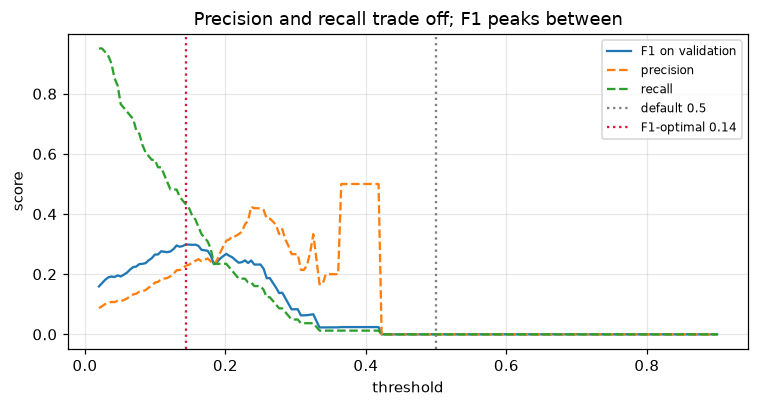

threshold                 precision   recall       F1   flagged
----------------------------------------------------------------
default 0.5                   0.000    0.000    0.000         0
F1-optimal 0.14               0.229    0.432    0.299       153

Moving one number took recall from near-nothing to something a retention team can
act on. The MODEL did not change at all - same coefficients, same AUC.


In [23]:
# The validation split and its predictions were made back at the split; reuse them.
thresholds = np.linspace(0.02, 0.9, 200)
f1_curve = [f1_score(y_val, (val_proba >= t).astype(int), zero_division=0) for t in thresholds]
best_f1_t = thresholds[int(np.argmax(f1_curve))]

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(thresholds, f1_curve, label="F1 on validation")
ax.plot(thresholds, [precision_score(y_val, (val_proba >= t).astype(int), zero_division=0)
                     for t in thresholds], label="precision", ls="--")
ax.plot(thresholds, [recall_score(y_val, (val_proba >= t).astype(int))
                     for t in thresholds], label="recall", ls="--")
ax.axvline(0.5, color="gray", ls=":", label="default 0.5")
ax.axvline(best_f1_t, color="crimson", ls=":", label=f"F1-optimal {best_f1_t:.2f}")
ax.set(xlabel="threshold", ylabel="score", title="Precision and recall trade off; F1 peaks between")
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"{'threshold':<24} {'precision':>10} {'recall':>8} {'F1':>8} {'flagged':>9}")
print("-" * 64)
for label, t in [("default 0.5", 0.5), (f"F1-optimal {best_f1_t:.2f}", best_f1_t)]:
    p = (val_proba >= t).astype(int)
    print(f"{label:<24} {precision_score(y_val, p, zero_division=0):>10.3f} "
          f"{recall_score(y_val, p):>8.3f} {f1_score(y_val, p):>8.3f} {p.sum():>9}")
print()
print("Moving one number took recall from near-nothing to something a retention team can")
print("act on. The MODEL did not change at all - same coefficients, same AUC.")

## 3.1 The threshold is a cost decision, not an F1 decision

F1 is a reasonable default when you have no cost information, but it encodes a specific and
usually false assumption: **that a false positive and a false negative cost the same**.

They almost never do. Put real numbers on them and the answer changes.

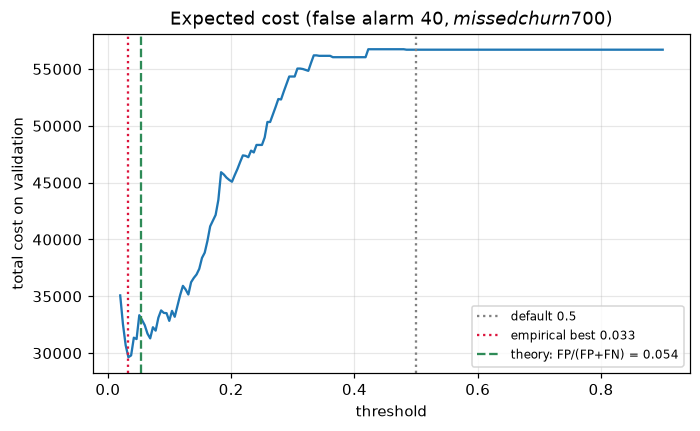

threshold                        cost   false alarms   missed
--------------------------------------------------------------
default 0.5                    56,700              0       81
F1-optimal 0.144               36,920            118       46
cost-optimal 0.033             29,640            636        6

The optimal threshold has a CLOSED FORM: t* = C_FP / (C_FP + C_FN) = 0.054.
Derivation: flag a customer when the expected cost of flagging is lower than the
cost of not flagging, i.e. (1-p)*C_FP < p*C_FN, which rearranges to
p > C_FP/(C_FP+C_FN). It depends only on the RATIO of the costs, not their size.

The empirical minimum (0.033) is in the same region as the theoretical
one (0.054) but not identical, and the gap is informative rather than
worrying: the cost curve is very flat near its minimum (look at the plot), and the
validation set contains only ~80 churners, so the empirical argmin is noisy.

Prefer the FORMULA when your probabilities are calibrated - it uses no data at 

In [24]:
COST_FALSE_ALARM = 40      # a retention offer wasted on someone who was staying anyway
COST_MISSED_CHURN = 700    # a customer lost

def total_cost(y_true, proba, t):
    pred = (proba >= t).astype(int)
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    return fp * COST_FALSE_ALARM + fn * COST_MISSED_CHURN, fp, fn

costs = np.array([total_cost(y_val.to_numpy(), val_proba, t)[0] for t in thresholds])
best_cost_t = thresholds[int(costs.argmin())]

# The theoretically optimal threshold, if probabilities are calibrated:
theoretical = COST_FALSE_ALARM / (COST_FALSE_ALARM + COST_MISSED_CHURN)

plt.plot(thresholds, costs)
plt.axvline(0.5, color="gray", ls=":", label="default 0.5")
plt.axvline(best_cost_t, color="crimson", ls=":", label=f"empirical best {best_cost_t:.3f}")
plt.axvline(theoretical, color="seagreen", ls="--",
            label=f"theory: FP/(FP+FN) = {theoretical:.3f}")
plt.xlabel("threshold"); plt.ylabel("total cost on validation")
plt.title(f"Expected cost (false alarm ${COST_FALSE_ALARM}, missed churn ${COST_MISSED_CHURN})")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.show()

print(f"{'threshold':<26} {'cost':>10} {'false alarms':>14} {'missed':>8}")
print("-" * 62)
for label, t in [("default 0.5", 0.5), (f"F1-optimal {best_f1_t:.3f}", best_f1_t),
                 (f"cost-optimal {best_cost_t:.3f}", best_cost_t)]:
    c, fp, fn = total_cost(y_val.to_numpy(), val_proba, t)
    print(f"{label:<26} {c:>10,} {fp:>14} {fn:>8}")

print()
print(f"The optimal threshold has a CLOSED FORM: t* = C_FP / (C_FP + C_FN) = {theoretical:.3f}.")
print("Derivation: flag a customer when the expected cost of flagging is lower than the")
print("cost of not flagging, i.e. (1-p)*C_FP < p*C_FN, which rearranges to")
print("p > C_FP/(C_FP+C_FN). It depends only on the RATIO of the costs, not their size.")
print()
print(f"The empirical minimum ({best_cost_t:.3f}) is in the same region as the theoretical")
print(f"one ({theoretical:.3f}) but not identical, and the gap is informative rather than")
print("worrying: the cost curve is very flat near its minimum (look at the plot), and the")
print("validation set contains only ~80 churners, so the empirical argmin is noisy.")
print()
print("Prefer the FORMULA when your probabilities are calibrated - it uses no data at all,")
print("so it cannot overfit. Use the empirical sweep as a sanity check, or as the fallback")
print("when you cannot trust calibration. Note both beat the default 0.5 by a wide margin.")
print()
print("And that formula is worthless on an UNcalibrated model, because it treats p as a")
print("real probability. Which is the subject of 3.2.")

In [25]:
# Doing it properly with sklearn, cross-validated inside the training data.
tuned = TunedThresholdClassifierCV(
    churn_pipeline(), scoring="f1", cv=5, random_state=RANDOM_STATE,
).fit(X_train, y_train)

print(f"threshold chosen by CV        : {tuned.best_threshold_:.3f}")
print(f"threshold from our manual sweep: {best_f1_t:.3f}")
print(f"validation F1 at the CV threshold: "
      f"{f1_score(y_val, (val_proba >= tuned.best_threshold_).astype(int)):.4f}")
print()
print("Two honest procedures landing close together is the sanity check. Prefer this over")
print("the manual sweep: it averages over 5 folds instead of trusting one validation split.")
print()
print("For cost-based tuning, pass a custom scorer built from your cost matrix:")
print("  from sklearn.metrics import make_scorer")
print("  cost_scorer = make_scorer(my_negative_cost, response_method='predict')")
print("  TunedThresholdClassifierCV(model, scoring=cost_scorer)")

threshold chosen by CV        : 0.110
threshold from our manual sweep: 0.144
validation F1 at the CV threshold: 0.2724

Two honest procedures landing close together is the sanity check. Prefer this over
the manual sweep: it averages over 5 folds instead of trusting one validation split.

For cost-based tuning, pass a custom scorer built from your cost matrix:
  from sklearn.metrics import make_scorer
  cost_scorer = make_scorer(my_negative_cost, response_method='predict')
  TunedThresholdClassifierCV(model, scoring=cost_scorer)


## 3.2 `class_weight='balanced'`: what it buys and what it costs

The other standard response to imbalance. It re-weights the loss so each class contributes
equally in total:

$$ w_k = \frac{n}{K \cdot n_k} $$

On our 7% data that makes each churner worth about 7× a non-churner during fitting.

It is genuinely useful — and it has a consequence almost nobody mentions.

In [26]:
weighted = churn_pipeline(class_weight="balanced").fit(X_fit, y_fit)
w_proba = weighted.predict_proba(X_val)[:, 1]

n_neg, n_pos = (y_fit == 0).sum(), (y_fit == 1).sum()
print(f"implied weights: class 0 -> {len(y_fit)/(2*n_neg):.3f}, "
      f"class 1 -> {len(y_fit)/(2*n_pos):.3f}   (a churner counts "
      f"{(len(y_fit)/(2*n_pos))/(len(y_fit)/(2*n_neg)):.1f}x)")

print(f"\n{'model':<26} {'AUC':>7} {'AP':>8} {'recall@0.5':>11} {'mean p':>8} {'Brier':>8} {'log-loss':>9}")
print("-" * 82)
for label, proba in [("plain", val_proba), ("class_weight='balanced'", w_proba)]:
    pred = (proba >= 0.5).astype(int)
    print(f"{label:<26} {roc_auc_score(y_val, proba):>7.4f} "
          f"{average_precision_score(y_val, proba):>8.4f} {recall_score(y_val, pred):>11.4f} "
          f"{proba.mean():>8.4f} {brier_score_loss(y_val, proba):>8.4f} "
          f"{log_loss(y_val, proba):>9.4f}")
print(f"{'actual churn rate':<26} {'':<7} {'':<8} {'':<11} {y_val.mean():>8.4f}")

print()
print("Read the columns carefully, because they tell opposite stories:")
print("  RANKING  (AUC, AP)      -  essentially unchanged. It did not learn anything new.")
print("  RECALL at 0.5           -  hugely improved. This is why people reach for it.")
print(f"  MEAN PREDICTED p        -  now {w_proba.mean()/y_val.mean():.1f}x the true churn rate. The probabilities are LIES.")
print("  Brier / log-loss        -  much worse. Careful how you read these: they are")
print("                             PROPER SCORES, mixing calibration with discrimination,")
print("                             not calibration measures. Since ranking barely moved,")
print("                             the deterioration here is calibration - but confirm")
print("                             that on the reliability curve below, not from these.")
print()
rank_corr = pd.Series(val_proba).corr(pd.Series(w_proba), method="spearman")
print("What actually happened, and how far it generalises:")
print()
print("Re-weighting by a per-CLASS constant mostly slides the intercept, lifting every")
print("probability. In the population, for a correctly specified unpenalised logistic")
print("model, that is exactly what it does - the slopes are unchanged and only the")
print("intercept moves, which is why it is often described as a threshold change in")
print("disguise.")
print()
print(f"On finite data it is only approximately that. Spearman rank correlation between")
print(f"the two score vectors is {rank_corr:.4f} - very close to 1, but not 1, so a few pairs")
print("did swap. Add regularisation, or misspecify the model, and the slopes move too:")
print("the weights change the objective, not merely the cut-off.")
print()
print("What is not approximate is the damage to calibration, which is the real cost here.")

implied weights: class 0 -> 0.539, class 1 -> 6.888   (a churner counts 12.8x)

model                          AUC       AP  recall@0.5   mean p    Brier  log-loss
----------------------------------------------------------------------------------
plain                       0.7477   0.2116      0.0000   0.0720   0.0621    0.2301
class_weight='balanced'     0.7461   0.2117      0.6790   0.4088   0.2038    0.5869
actual churn rate                                         0.0720

Read the columns carefully, because they tell opposite stories:
  RANKING  (AUC, AP)      -  essentially unchanged. It did not learn anything new.
  RECALL at 0.5           -  hugely improved. This is why people reach for it.
  MEAN PREDICTED p        -  now 5.7x the true churn rate. The probabilities are LIES.
  Brier / log-loss        -  much worse. Careful how you read these: they are
                             PROPER SCORES, mixing calibration with discrimination,
                             not calibration

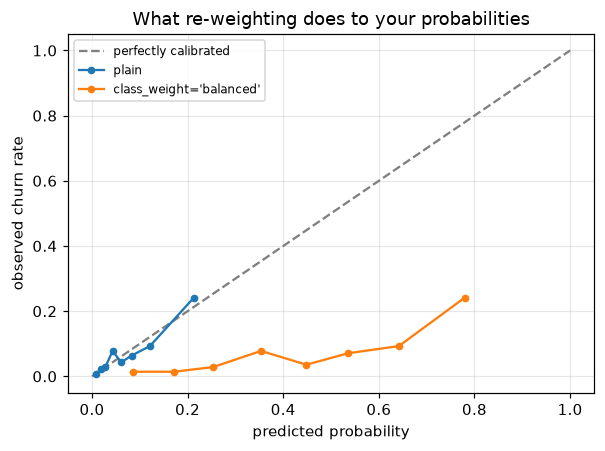

The plain model tracks the diagonal: when it says 20%, about 20% churn.
The balanced model sits far BELOW it: when it says 60%, far fewer than 60% churn.

If you only ever threshold the output, this does not matter. If anyone downstream
multiplies your probability by a customer value, or sums it to forecast next
quarter's churn count, it matters enormously - the forecast would be 5.7x too high.


In [27]:
fig, ax = plt.subplots(figsize=(5.6, 4.2))
ax.plot([0, 1], [0, 1], "--", color="gray", label="perfectly calibrated")
for label, proba in [("plain", val_proba), ("class_weight='balanced'", w_proba)]:
    frac_pos, mean_pred = calibration_curve(y_val, proba, n_bins=8, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", ms=4, label=label)
ax.set(xlabel="predicted probability", ylabel="observed churn rate",
       title="What re-weighting does to your probabilities")
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("The plain model tracks the diagonal: when it says 20%, about 20% churn.")
print("The balanced model sits far BELOW it: when it says 60%, far fewer than 60% churn.")
print()
print("If you only ever threshold the output, this does not matter. If anyone downstream")
print("multiplies your probability by a customer value, or sums it to forecast next")
print(f"quarter's churn count, it matters enormously - the forecast would be {w_proba.mean()/y_val.mean():.1f}x too high.")

### So which knob should you turn?

| Goal | Use | Why |
|---|---|---|
| Better recall, probabilities still meaningful | **Move the threshold** | Changes only the decision, leaves probabilities intact |
| Cost-sensitive decisions with known costs | **Threshold at $C_{FP}/(C_{FP}+C_{FN})$** | Provably optimal *if* calibrated |
| Model barely learns the rare class at all | `class_weight="balanced"` | Genuinely helps when the minority is tiny (<1%) or the model underfits it |
| Need both recall *and* honest probabilities | `class_weight` **then** `CalibratedClassifierCV` | Re-weight to learn, then recalibrate to report |

**The default recommendation for logistic regression: move the threshold, do not re-weight.**
Logistic regression fitted by plain maximum likelihood is naturally well calibrated, and
that is one of the main reasons to choose it. Re-weighting throws that away to fix a problem
the threshold already solves.

`class_weight` earns its place with models that genuinely fail to learn the minority class,
or with extreme imbalance where the rare class barely influences the loss at all.

In [28]:
# If you must re-weight, recalibrate afterwards.
recalibrated = CalibratedClassifierCV(
    churn_pipeline(class_weight="balanced"), method="sigmoid", cv=5,
).fit(X_fit, y_fit)
r_proba = recalibrated.predict_proba(X_val)[:, 1]

print(f"{'model':<34} {'mean p':>8} {'actual':>8} {'Brier':>8} {'log-loss':>9} {'AUC':>8}")
print("-" * 80)
for label, proba in [("plain (already calibrated)", val_proba),
                     ("class_weight='balanced'", w_proba),
                     ("balanced + sigmoid calibration", r_proba)]:
    print(f"{label:<34} {proba.mean():>8.4f} {y_val.mean():>8.4f} "
          f"{brier_score_loss(y_val, proba):>8.4f} {log_loss(y_val, proba):>9.4f} "
          f"{roc_auc_score(y_val, proba):>8.4f}")

print()
print("Calibration pulls the mean prediction back to the true rate and repairs Brier and")
print("log-loss, while barely touching AUC. 'Barely' rather than 'not at all': a single")
print("strictly monotone transform of one fixed score cannot reorder anything, but")
print("CalibratedClassifierCV fits one sigmoid per fold and averages them, and that")
print("average can nudge a few pairs. Expect ranking metrics to move slightly, not to")
print("improve - the point of calibration is the probabilities.")
print()
print("Note the plain model is already as good as the calibrated one. That is the point:")
print("we broke calibration ourselves and then spent a 5-fold CalibratedClassifierCV")
print("putting it back. Not re-weighting in the first place was free.")
print()
print("method='sigmoid' (Platt scaling) fits a 1-D logistic on the scores - robust, needs")
print("little data. method='isotonic' is non-parametric and more flexible, but needs more")
print("data and can overfit below ~1000 samples.")

model                                mean p   actual    Brier  log-loss      AUC
--------------------------------------------------------------------------------
plain (already calibrated)           0.0720   0.0720   0.0621    0.2301   0.7477
class_weight='balanced'              0.4088   0.0720   0.2038    0.5869   0.7461
balanced + sigmoid calibration       0.0723   0.0720   0.0622    0.2305   0.7459

Calibration pulls the mean prediction back to the true rate and repairs Brier and
log-loss, while barely touching AUC. 'Barely' rather than 'not at all': a single
strictly monotone transform of one fixed score cannot reorder anything, but
CalibratedClassifierCV fits one sigmoid per fold and averages them, and that
average can nudge a few pairs. Expect ranking metrics to move slightly, not to
improve - the point of calibration is the probabilities.

Note the plain model is already as good as the calibrated one. That is the point:
we broke calibration ourselves and then spent a 5-fold Cali

## 3.3 The final test, once

Every choice is now locked: features, pipeline, no re-weighting, threshold chosen by
cross-validation on the training data. We unseal the test set and report.

In [29]:
# The first and only time the test set is scored. Everything above - the diagnostics,
# the threshold, the class-weight decision - was settled on validation data or by
# cross-validation inside the training set.
test_proba = churn_model.predict_proba(X_test)[:, 1]

final_threshold = tuned.best_threshold_
final_pred = (test_proba >= final_threshold).astype(int)

print(f"final model    : logistic regression, unpenalised, threshold {final_threshold:.3f}")
print(f"chosen by      : 5-fold CV on the training data only")
print()
print(classification_report(y_test, final_pred, target_names=["stay", "churn"], digits=3))
print(f"ROC-AUC {roc_auc_score(y_test, test_proba):.4f}   "
      f"AP {average_precision_score(y_test, test_proba):.4f}   "
      f"(base rate {y_test.mean():.4f})")
cost, fp, fn = total_cost(y_test.to_numpy(), test_proba, final_threshold)
base_cost, _, base_fn = total_cost(y_test.to_numpy(), np.zeros(len(y_test)), 0.5)
print(f"\ncost at this threshold: ${cost:,}   vs ${base_cost:,} for doing nothing"
      f"  ({1 - cost/base_cost:.0%} saving)")

print()
print("How to report this honestly:")
print(f"  'The model ranks churn risk with AUC {roc_auc_score(y_test, test_proba):.2f}. At the")
print(f"   chosen threshold it flags {final_pred.sum()} of {len(y_test)} customers, catching")
print(f"   {recall_score(y_test, final_pred):.0%} of churners at "
      f"{precision_score(y_test, final_pred, zero_division=0):.0%} precision. Its probabilities")
print("   look well calibrated on held-out data, so they can be used for")
print("   expected-value calculations - a property worth re-checking on new data. It")
print("   cannot explain WHY a customer churns, and the coefficients are associations,")
print("   not causes - the two-year contract effect is very likely partly selection.'")
print()
print("That last sentence is the difference between a data scientist and someone who")
print("reports an AUC and stops.")

final model    : logistic regression, unpenalised, threshold 0.110
chosen by      : 5-fold CV on the training data only

              precision    recall  f1-score   support

        stay      0.956     0.800     0.871      1392
       churn      0.170     0.528     0.257       108

    accuracy                          0.780      1500
   macro avg      0.563     0.664     0.564      1500
weighted avg      0.900     0.780     0.827      1500

ROC-AUC 0.7536   AP 0.1779   (base rate 0.0720)

cost at this threshold: $46,860   vs $75,600 for doing nothing  (38% saving)

How to report this honestly:
  'The model ranks churn risk with AUC 0.75. At the
   chosen threshold it flags 336 of 1500 customers, catching
   53% of churners at 17% precision. Its probabilities
   look well calibrated on held-out data, so they can be used for
   expected-value calculations - a property worth re-checking on new data. It
   cannot explain WHY a customer churns, and the coefficients are associations,
   n

***
# Part 4 - Tough questions

Answer each **before** expanding it. If you can answer 10 of these 12 out loud, without
looking, you understand logistic regression better than most people who list it on a CV.

***

### Q1. Logistic regression is called *regression* but does classification. What exactly is being regressed, and on what scale?

<details><summary>Answer</summary>

**The log-odds are being regressed, linearly, on the features.**

The model's actual claim is $\log\frac{p}{1-p} = w^\top x + b$ — a linear model whose response
variable is the log-odds of the outcome, not the outcome itself. Everything else follows:

- the sigmoid is just the inverse of that link, applied to get back to a probability
- coefficients are additive on the log-odds scale, which is why they are multiplicative on
  the odds scale (an odds ratio)
- the decision boundary is $z = 0$, a **hyperplane in feature space** — so logistic
  regression is a linear classifier, and cannot separate XOR any more than a perceptron can

In the language of generalised linear models: the family is Bernoulli and the link function
is the logit. Swap the link for a probit (normal CDF) and you get probit regression, which
is nearly identical in practice and loses the clean odds-ratio interpretation.

</details>

***

### Q2. Why is squared error a bad loss here? Give two independent reasons, one about optimisation and one about learning signal.

<details><summary>Answer</summary>

**Reason 1 — non-convexity.** Composing the sigmoid with a squared error gives a loss that is
*not convex in the weights*. It has local minima and saddle points, so gradient descent's
answer depends on initialisation and the solution is not unique. Section 1.3 demonstrates
this by finding negative Hessian eigenvalues. Log-loss's Hessian is
$X^\top \text{diag}(p(1-p)) X$, which is positive semi-definite because every $p(1-p) > 0$ —
convex, one optimum, reachable from anywhere.

**Reason 2 — vanishing gradients.** Differentiating squared error through the sigmoid leaves
a factor of $\sigma'(z) = p(1-p)$, which goes to zero in the saturated tails. So a prediction
that is *confidently wrong* generates almost no gradient — at $z = -10$ with $y=1$, the
gradient is about $9\times10^{-5}$. The model has no pressure to fix its worst errors.
Log-loss is constructed so that factor cancels exactly, leaving $\nabla_z = p - y$, which is
**largest when the model is most wrong**.

The third reason, if asked: log-loss is not a hack to fix these — it *is* the negative
log-likelihood of the Bernoulli model, so minimising it is maximum-likelihood estimation and
inherits all of MLE's asymptotic properties.

</details>

***

### Q3. Linear regression has a closed-form solution. Why doesn't logistic regression, and does that mean it's harder to fit?

<details><summary>Answer</summary>

Setting the gradient to zero gives $X^\top(\sigma(Xw) - y) = 0$. Because $\sigma$ is
non-linear, $w$ appears *inside* it and cannot be algebraically isolated — unlike least
squares, where the same step gives $X^\top X w = X^\top y$ and you just solve the linear
system.

**But it is not harder in any way that matters.** The loss is convex and smooth, so:

- there is exactly one optimum
- any reasonable iterative method finds it
- Newton-type solvers (`lbfgs`, `newton-cholesky`) converge in tens of iterations by using
  curvature information

The classical algorithm is **IRLS** (iteratively reweighted least squares), which is just
Newton's method on this loss, and each step turns out to be a *weighted least squares fit* —
so logistic regression is literally solved by repeating linear regression with the weights
updated each round.

The one genuine failure case is perfect separation (Q7), where no finite optimum exists.

</details>

***

### Q4. A coefficient is 0.693. State precisely what that means — and what it does *not* mean.

<details><summary>Answer</summary>

$e^{0.693} = 2.0$, so: **holding all other features fixed, a one-unit increase in this
feature multiplies the *odds* of the positive class by 2.**

What it does **not** mean:

- **Not "doubles the probability."** Odds are $p/(1-p)$, not $p$. Doubling odds from 0.01
  ($p{=}0.0099$) gives $p{=}0.0196$ — roughly double. Doubling odds from 4 ($p{=}0.8$) gives
  $p{=}0.89$ — an 11% increase. The odds ratio is constant; the probability effect is not.
- **Not "increases probability by 69%."** That confuses the log-odds coefficient with a
  percentage.
- **Not necessarily "per one natural unit"** — if the feature was standardised, "one unit" is
  one standard deviation.
- **Not causal.** On observational data it is an association. "Holding all else fixed" is
  also only meaningful if the features *can* move independently — with correlated features
  the split between them is arbitrary.

The safe way to present it: convert to the probability change **at the stakeholder's actual
operating point**, and say "associated with".

</details>

***

### Q5. In sklearn, `C=0.01` and `alpha=0.01` mean opposite things. Explain.

<details><summary>Answer</summary>

`Ridge(alpha=)` multiplies the **penalty**: $\text{loss} + \alpha\lVert w\rVert^2$. Bigger
alpha, stronger regularization.

`LogisticRegression(C=)` multiplies the **data term**:
$C\sum_i \text{log-loss}_i + \frac{1}{2}\lVert w\rVert^2$. So `C` is *inverse* regularization
strength — **smaller C means a stronger penalty**, and $C \approx 1/\alpha$.

`C=0.01` is heavy regularization; `alpha=0.01` is almost none.

Two related traps worth knowing:

- **`LogisticRegression` regularizes by default** (`penalty="l2"`, `C=1.0`), unlike
  `LinearRegression`, which does not. To get true maximum-likelihood coefficients you must
  pass `penalty=None` (or, as an approximation, a large `C`). Anyone comparing sklearn's coefficients to statsmodels'
  and finding a mismatch has usually hit this.
- Because the penalty acts on raw coefficient magnitudes, **features must be scaled** or the
  penalty falls unequally across features purely because of their units.

</details>

***

### Q6. Your model has ROC-AUC 0.83 but recall 0.09 at the default threshold. Is the model bad?

<details><summary>Answer</summary>

**Probably not the model — check the threshold and the calibration first.**

AUC 0.83 means the ranking is genuinely informative: a random positive is scored above a
random negative 83% of the time. Recall 0.09 means that at a cut of 0.5 almost nothing clears
the bar — which is exactly what you expect when the base rate is 7%, because a calibrated
model will rarely output above 0.5 for anything.

These measure different things:

- **AUC / average precision / log-loss** evaluate the *model* — they are threshold-free.
- **precision / recall / F1 / accuracy** evaluate a *decision rule*, which is model **plus**
  threshold.

The fix costs nothing: move the threshold down (Part 3), choosing it on validation data, from
costs if you have them. Nothing about the coefficients changes.

The diagnostic instinct to build: whenever recall is near zero on imbalanced data, **check
AUC before touching the model**. High AUC with low recall points at the threshold; low AUC
with low recall points at the model.

Two caveats on "the model is fine". A good ranking does not guarantee good *probabilities* —
the scores can be badly calibrated, which matters the moment anyone does expected-value
arithmetic with them, so check a reliability curve too. And AUC measured on your validation
data says nothing about a deployment population that has since shifted.

</details>

***

### Q7. Your classes are perfectly separable and the coefficients explode toward infinity with a convergence warning. What is happening, and what are the two very different fixes?

<details><summary>Answer</summary>

With perfectly separable data, the **maximum-likelihood solution does not exist**. For any
weight vector that separates the classes, scaling it up by 10 pushes every predicted
probability closer to 0 or 1, which strictly lowers the log-loss. There is no finite optimum
— the likelihood improves forever as $\lVert w\rVert \to \infty$.

**Fix 1 — regularise.** Any $C < \infty$ adds a penalty that grows with $\lVert w\rVert$, so
the total objective now has a finite minimum. This is the direct analogue of ridge making a
singular $X^\top X$ invertible, and it is why sklearn regularizes by default rather than
letting you discover this.

**Fix 2 — go and check for leakage, first.** In practice, perfectly separable real data
almost always means a feature is a proxy for the label: an ID that encodes the outcome, a
field populated only after the event, a duplicated target column. Silencing it with a penalty
would ship a broken model that scores perfectly in your notebook.

So: **diagnose before you regularise.** Separation is a symptom, and leakage is the first
cause to rule out — but genuine separation is common enough in small samples, sparse
categories and high-dimensional data that finding no leakage does not mean you have missed
something.
(Firth's penalised likelihood is the principled statistical fix when the separation is genuine
and you need inference.)

</details>

***

### Q8. `class_weight='balanced'` improves recall a lot and leaves AUC unchanged. What did it actually do, and what did it break?

<details><summary>Answer</summary>

**What it did:** re-weighted the loss so the rare class contributes as much in total as the
common one ($w_k = n / (K \cdot n_k)$). The dominant effect is a **shift in the intercept**,
which slides every predicted probability upward. Because it moves all scores in the same
direction, it barely changes their *order* — which is why AUC and AP are essentially
unchanged.

**What it broke: calibration.** Predicted probabilities are now systematically far too high —
in Part 3.2 the mean prediction goes from matching the 7% base rate to roughly 4× it. Brier
score and log-loss get much worse, because those metrics measure exactly this.

**The deeper point:** since it mostly shifts the intercept and leaves the ranking alone, it is
**a threshold change in disguise** — and a threshold change is the cleaner way to get the same
recall without breaking anything.

**When it is still worth it:** extreme imbalance (well under 1%), where the minority class
contributes so little to the loss that the model genuinely underfits it, or models that do not
optimise a proper scoring rule. If you use it and need probabilities, wrap it in
`CalibratedClassifierCV`.

</details>

***

### Q9. You have costs: a false alarm costs \$40, a missed churner costs \$700. Derive the optimal threshold, and state the assumption that makes it valid.

<details><summary>Answer</summary>

Flag a customer when the expected cost of flagging is lower than the expected cost of not:

$$ (1-p)\cdot C_{FP} \;<\; p \cdot C_{FN} $$

Rearranging:

$$ p \;>\; \frac{C_{FP}}{C_{FP} + C_{FN}} = \frac{40}{40+700} = 0.054 $$

So flag anyone above **5.4%**, not 50%. Note it depends only on the *ratio* of costs, not
their absolute size.

**The assumption: the probabilities must be calibrated.** The derivation treats $p$ as a real
probability. If your model is uncalibrated — because you used `class_weight='balanced'`,
resampled, SMOTE'd, or used a model that does not produce proper probabilities — then $p$ is
just a score, the inequality is meaningless, and the formula gives the wrong threshold.

This is the single best argument for keeping logistic regression calibrated: it makes the
optimal decision rule a one-line calculation instead of a search.

(If you cannot calibrate, fall back to sweeping the threshold empirically against realised
cost on a validation set — which is what Part 3.1 does as a cross-check.)

</details>

***

### Q10. Why can ROC-AUC look flattering on heavily imbalanced data, and what should you report instead?

<details><summary>Answer</summary>

First, the thing that is *not* happening: prevalence does not inflate ROC-AUC. Both its axes
are rates computed within a single class, so for a fixed pair of score distributions ROC-AUC
is unchanged if you resample the classes to a different balance. It is a pure ranking
statistic — the probability a random positive outranks a random negative.

What imbalance changes is what a given FPR *costs*. With negatives massively outnumbering
positives, an FPR small enough to look negligible still means a large **count** of false
positives — 1% of 100,000 negatives is 1,000 of them, which can swamp a few hundred true
positives. ROC-AUC is not wrong about this; it simply does not display it.

**Report average precision (AP) alongside it.** Precision is $TP/(TP+FP)$ — it contains **no
true-negative term at all**, so it reports that burden directly.

Two things to remember when reporting it:

- **AP's random baseline is the base rate**, not 0.5. An AP of 0.18 on a 7% problem is ~2.5×
  better than random, which sounds much less impressive than an AUC of 0.75 and is more
  informative.
- Because the baseline moves with prevalence, **AP is not comparable across datasets with
  different class balance**, while ROC-AUC is. That is ROC's genuine advantage.

Report both, alongside the base rate. And if the decision is "who do we call with 100 phone
calls", report **precision@k** — the metric that actually matches the operation.

</details>

***

### Q11. Adding a feature changes the sign of an existing coefficient. Is something broken?

<details><summary>Answer</summary>

**No — this is expected and often the most informative thing that happens all week.**

A coefficient means "the effect of this feature *holding the other features in the model
fixed*". Change the set of other features and you have changed the question, so the answer
can legitimately change, including its sign. This is **omitted variable bias** / Simpson's
paradox.

Concretely: `monthly_charges` might look protective on its own, because expensive plans are
bought by long-tenure loyal customers. Add `tenure_months` and the charge coefficient can flip
positive — now you are comparing customers *at the same tenure*, and among those, the
expensive ones churn more.

Which sign is "right" depends on the question:

- *"What happens if we raise prices for a given customer?"* → you want the controlled effect,
  so include tenure.
- *"Which customers should we call?"* → you only need prediction, and the sign does not matter.

Two warnings: (1) this is a **causal** question, and you cannot settle it with p-values —
controlling for the wrong variable (a collider, or a mediator on the causal path) *introduces*
bias rather than removing it. (2) A sign flip can also mean **multicollinearity**, where the
split of credit between correlated features is arbitrary — check VIF before believing either
version.

</details>

***

### Q12. Logistic regression cannot solve XOR. Explain why, and give two ways to fix it that keep it a logistic regression.

<details><summary>Answer</summary>

The decision boundary is $w^\top x + b = 0$ — a **hyperplane**. XOR ($y=1$ when exactly one of
$x_1, x_2$ is 1) requires two disjoint regions on opposite corners, which no single straight
line can separate. The model is linear **in the features it is given**, so no amount of data,
regularization or solver-tuning fixes it.

Both fixes work by changing the features, not the model:

**1. Interaction terms.** Add $x_1 x_2$ as a third feature. XOR becomes linearly separable in
that 3-D space: $y = x_1 + x_2 - 2x_1x_2$. `PolynomialFeatures(degree=2, interaction_only=True)`
does this. This is the same trick as fitting curves with linear regression — "linear" refers
to linearity in the *parameters*, not the features.

**2. Basis expansion.** Splines, RBF features, or `Nystroem`/`RBFSampler` map into a higher
dimensional space where a hyperplane suffices. This is the kernel trick, made explicit.

**The catch, and the real lesson:** both require you to *know which* interaction to add. With
20 features there are 190 pairwise interactions and vastly more higher-order ones. Tree
ensembles find them automatically, which is precisely why they dominate tabular competitions.

The practical test from Part 2: if a gradient-boosted tree substantially beats your logistic
regression, that gap is a *measurement of the non-linear structure you have not encoded*. Go
add features, then re-measure.

</details>

***

## Coding challenges

Try each before expanding the solution below it.

In [30]:
# ---------------------------------------------------------------------------
# CHALLENGE 1
# Implement Newton's method (IRLS) for logistic regression from scratch:
#
#     w <- w + (X^T W X)^-1 X^T (y - p),     W = diag(p(1-p))
#
# Verify it matches sklearn, and compare how many ITERATIONS it needs versus
# the gradient descent from Part 1.4 (which needed 5,000).
# ---------------------------------------------------------------------------

# YOUR CODE HERE

In [31]:
# --- Challenge 1: one solution ------------------------------------------
def fit_logistic_newton(X, y, iterations=10, ridge=1e-8):
    """IRLS / Newton's method. `ridge` keeps the Hessian invertible."""
    n, p = X.shape
    D = np.hstack([X, np.ones((n, 1))])          # design matrix with intercept
    theta = np.zeros(p + 1)
    history = []

    for _ in range(iterations):
        prob = expit(D @ theta)
        W = prob * (1 - prob)                    # the diagonal of the weight matrix
        gradient = D.T @ (y - prob)
        hessian = (D * W[:, None]).T @ D + ridge * np.eye(p + 1)
        theta += np.linalg.solve(hessian, gradient)
        history.append(-np.mean(y * np.log(prob + 1e-12)
                                + (1 - y) * np.log(1 - prob + 1e-12)))
    return theta[:-1], theta[-1], history


w_n, b_n, hist_n = fit_logistic_newton(X_gd, y_gd, iterations=10)
sk_ref = LogisticRegression(penalty=None, max_iter=5000).fit(X_gd, y_gd)

print("Newton (10 iters):", np.round(w_n, 6), round(b_n, 6))
print("sklearn          :", np.round(sk_ref.coef_[0], 6), round(sk_ref.intercept_[0], 6))
print(f"max abs difference: {np.abs(w_n - sk_ref.coef_[0]).max():.2e}")
print()
print(f"{'iteration':>10} {'Newton log-loss':>18} {'gradient descent':>18}")
print("-" * 50)
for i in [0, 1, 2, 3, 5, 9]:
    print(f"{i:>10} {hist_n[i]:>18.8f} {history[i]:>18.8f}")
print()
print("Newton converges to 8 decimal places in about 5 iterations; gradient descent")
print("needed 5,000. That is the payoff for using curvature: each step solves a local")
print("quadratic approximation instead of taking a small step downhill.")
print()
print("The cost is the Hessian: O(n*p^2) to build and O(p^3) to solve, per iteration.")
print("Fine for hundreds of features, hopeless for a million - which is exactly when")
print("you switch to 'saga' or SGDClassifier.")

Newton (10 iters): [ 1.628595 -1.655874  0.498416] -0.225032
sklearn          : [ 1.628385 -1.655786  0.497917] -0.225507
max abs difference: 4.99e-04

 iteration    Newton log-loss   gradient descent
--------------------------------------------------
         0         0.69314718         0.69314718
         1         0.45155049         0.64229644
         2         0.41847333         0.60354969
         3         0.41467100         0.57367423
         5         0.41459083         0.53161804
         9         0.41459083         0.48509095

Newton converges to 8 decimal places in about 5 iterations; gradient descent
needed 5,000. That is the payoff for using curvature: each step solves a local
quadratic approximation instead of taking a small step downhill.

The cost is the Hessian: O(n*p^2) to build and O(p^3) to solve, per iteration.
Fine for hundreds of features, hopeless for a million - which is exactly when
you switch to 'saga' or SGDClassifier.


In [32]:
# ---------------------------------------------------------------------------
# CHALLENGE 2
# Show that logistic regression cannot learn XOR, then fix it with an
# interaction term - without changing the model class.
#
# Build the 4-point XOR problem, fit logistic regression, report accuracy.
# Then add x1*x2 and report again. Print the learned coefficients and check
# they match the algebraic solution y = x1 + x2 - 2*x1*x2.
# ---------------------------------------------------------------------------

# YOUR CODE HERE

In [33]:
# --- Challenge 2: one solution ------------------------------------------
X_xor = np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y_xor = np.array([0, 1, 1, 0])

plain = LogisticRegression(penalty=None, max_iter=5000).fit(X_xor, y_xor)
print(f"plain logistic regression accuracy: {plain.score(X_xor, y_xor):.2f}   <- chance")
print("  predicted probabilities:", np.round(plain.predict_proba(X_xor)[:, 1], 4))
print("  every point gets ~0.5: no line can separate these, so the fit gives up")

# Add the interaction. interaction_only=True skips x1^2 and x2^2 (useless for binary).
X_inter = PolynomialFeatures(degree=2, interaction_only=True,
                             include_bias=False).fit_transform(X_xor)
fixed = LogisticRegression(penalty=None, max_iter=5000).fit(X_inter, y_xor)
print(f"\nwith x1*x2 added, accuracy: {fixed.score(X_inter, y_xor):.2f}")
print("  feature order: [x1, x2, x1*x2]")
print("  coefficients :", np.round(fixed.coef_[0], 3), " intercept:",
      round(fixed.intercept_[0], 3))
print("  probabilities:", np.round(fixed.predict_proba(X_inter)[:, 1], 4))
print()
print("The learned weights follow the pattern y = x1 + x2 - 2*x1*x2, scaled up by however")
print("much the (unpenalised) fit could inflate them - this data is separable in 3-D, so")
print("we are in the Q7 regime and the magnitudes run large. The SIGNS and their ratio")
print("(-2x the single terms) are the part that matters.")
print()
print("Lesson: 'linear model' constrains the shape of the boundary in the space you HAND")
print("it, not the space the data lives in. Change the space and you change what is")
print("learnable - without changing a single line of the model.")

plain logistic regression accuracy: 0.50   <- chance
  predicted probabilities: [0.5 0.5 0.5 0.5]
  every point gets ~0.5: no line can separate these, so the fit gives up

with x1*x2 added, accuracy: 1.00
  feature order: [x1, x2, x1*x2]
  coefficients : [ 14.4    14.4   -30.877]  intercept: -6.811
  probabilities: [1.100e-03 9.995e-01 9.995e-01 1.000e-04]

The learned weights follow the pattern y = x1 + x2 - 2*x1*x2, scaled up by however
much the (unpenalised) fit could inflate them - this data is separable in 3-D, so
we are in the Q7 regime and the magnitudes run large. The SIGNS and their ratio
(-2x the single terms) are the part that matters.

Lesson: 'linear model' constrains the shape of the boundary in the space you HAND
it, not the space the data lives in. Change the space and you change what is
learnable - without changing a single line of the model.


In [34]:
# ---------------------------------------------------------------------------
# CHALLENGE 3
# Prove that class_weight='balanced' is (mostly) an intercept shift.
#
# Fit two models on the same imbalanced data, one plain and one balanced.
# Then show that if you shift the PLAIN model's log-odds by a constant and
# re-threshold, you can reproduce the balanced model's recall almost exactly -
# and that the two models rank the samples nearly identically.
# ---------------------------------------------------------------------------

# YOUR CODE HERE

In [35]:
# --- Challenge 3: one solution ------------------------------------------
from scipy.stats import spearmanr

plain_lr = Pipeline([("prep", preprocess),
                     ("model", LogisticRegression(max_iter=2000, penalty=None))]).fit(X_train, y_train)
bal_lr = Pipeline([("prep", preprocess),
                   ("model", LogisticRegression(max_iter=2000, penalty=None,
                                                class_weight="balanced"))]).fit(X_train, y_train)

p_plain = plain_lr.predict_proba(X_test)[:, 1]
p_bal = bal_lr.predict_proba(X_test)[:, 1]

# 1. Do they RANK the same? (If it were a pure intercept shift, rank correlation = 1.)
rho = spearmanr(p_plain, p_bal).statistic
print(f"Spearman rank correlation between the two models' scores: {rho:.6f}")

# 2. Compare the coefficients: intercept vs slopes.
c_plain = plain_lr["model"].coef_[0]
c_bal = bal_lr["model"].coef_[0]
print(f"\nintercept   plain {plain_lr['model'].intercept_[0]:+.4f}   "
      f"balanced {bal_lr['model'].intercept_[0]:+.4f}   "
      f"shift {bal_lr['model'].intercept_[0] - plain_lr['model'].intercept_[0]:+.4f}")
print(f"slopes      max abs difference {np.abs(c_bal - c_plain).max():.4f}   "
      f"(mean |slope| {np.abs(c_plain).mean():.4f})")

# 3. Reproduce the balanced model's recall by only moving the plain model's threshold.
target_recall = recall_score(y_test, (p_bal >= 0.5).astype(int))
grid_t = np.linspace(0.001, 0.999, 2000)
recalls = np.array([recall_score(y_test, (p_plain >= t).astype(int)) for t in grid_t])
match_t = grid_t[int(np.argmin(np.abs(recalls - target_recall)))]

print(f"\nbalanced model recall at 0.5      : {target_recall:.4f}")
print(f"plain model, threshold {match_t:.3f}     : "
      f"{recall_score(y_test, (p_plain >= match_t).astype(int)):.4f}")
print(f"precision - balanced {precision_score(y_test, (p_bal >= 0.5).astype(int), zero_division=0):.4f}"
      f"   vs plain-rethresholded "
      f"{precision_score(y_test, (p_plain >= match_t).astype(int), zero_division=0):.4f}")
print()
print("Rank correlation is essentially 1, the slopes barely move, and the whole effect is")
print("in the intercept. Re-thresholding the plain model reproduces the same recall AND")
print("the same precision - while keeping calibrated probabilities.")
print()
print("That is the proof: on this problem class_weight bought nothing a threshold could")
print("not, and cost the probabilities. (It is not EXACTLY an intercept shift - the")
print("weighting does perturb the slopes slightly - but the residual is tiny here.)")

Spearman rank correlation between the two models' scores: 0.999924

intercept   plain -2.2369   balanced +0.3097   shift +2.5465
slopes      max abs difference 0.0932   (mean |slope| 0.6324)



balanced model recall at 0.5      : 0.7315
plain model, threshold 0.068     : 0.7315
precision - balanced 0.1426   vs plain-rethresholded 0.1350

Rank correlation is essentially 1, the slopes barely move, and the whole effect is
in the intercept. Re-thresholding the plain model reproduces the same recall AND
the same precision - while keeping calibrated probabilities.

That is the proof: on this problem class_weight bought nothing a threshold could
not, and cost the probabilities. (It is not EXACTLY an intercept shift - the
weighting does perturb the slopes slightly - but the residual is tiny here.)


***
# Part 5 - Five datasets to practise on

Ordered by difficulty. Each breaks a different assumption. All load through scikit-learn.

> The OpenML ones need an internet connection on first fetch, then cache in
> `~/scikit_learn_data/`. **Every loader below pins a version or `data_id`** — unpinned
> names both warn and make your results irreproducible.

| # | Dataset | Rows × cols | The skill it forces | Difficulty |
|---|---|---|---|---|
| 1 | **Breast cancer** | 569 × 30 | Clean baseline; separation and regularization | ★☆☆☆☆ |
| 2 | **Adult / census income** | 48,842 × 14 | Mixed types, missing values, fairness | ★★☆☆☆ |
| 3 | **German credit** | 1,000 × 20 | Asymmetric costs, tiny data | ★★★☆☆ |
| 4 | **Bank marketing** | 45,211 × 16 | Imbalance + a leakage trap | ★★★★☆ |
| 5 | **Digits (multiclass)** | 1,797 × 64 | Softmax, per-class errors | ★★★☆☆ |

In [36]:
# Check what is reachable from this machine. Safe to run: caches, and reports rather
# than raising if you are offline.
import warnings

from sklearn.datasets import fetch_openml


def load_digits_quietly():
    """load_digits emits a NumPy 2.5 DeprecationWarning from inside sklearn 1.9
    (it sets .shape on an array). Nothing to do with your code, and harmless -
    suppressed here only so this cell's output stays readable."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", DeprecationWarning)
        return load_digits(as_frame=True)


CATALOGUE = [
    ("Breast cancer",     lambda: load_breast_cancer(as_frame=True)),
    ("Adult (income)",    lambda: fetch_openml(name="adult", version=2, as_frame=True)),
    ("German credit",     lambda: fetch_openml(name="credit-g", version=1, as_frame=True)),
    ("Bank marketing",    lambda: fetch_openml(name="bank-marketing", version=1, as_frame=True)),
    ("Digits",            load_digits_quietly),
]

print(f"{'dataset':<18} {'rows':>7} {'cols':>6} {'NaN':>7} {'text':>6}  classes")
print("-" * 72)
for label, loader in CATALOGUE:
    try:
        b = loader()
        Xd, td = b.data, b.target
        n_text = len(Xd.select_dtypes(exclude="number").columns)
        classes = sorted(pd.Series(td).unique().tolist())[:4]
        print(f"{label:<18} {Xd.shape[0]:>7} {Xd.shape[1]:>6} "
              f"{int(Xd.isna().sum().sum()):>7} {n_text:>6}  {classes}")
    except Exception as exc:
        print(f"{label:<18} unavailable - {type(exc).__name__}: {str(exc)[:35]}")

dataset               rows   cols     NaN   text  classes
------------------------------------------------------------------------
Breast cancer          569     30       0      0  [0, 1]
Adult (income)       48842     14    6465      8  ['<=50K', '>50K']


German credit         1000     20       0     13  ['bad', 'good']


Bank marketing       45211     16       0      9  ['1', '2']
Digits                1797     64       0      0  [0, 1, 2, 3]


### 1. Breast cancer — the gentle start

```python
from sklearn.datasets import load_breast_cancer
bunch = load_breast_cancer(as_frame=True)
X, y = bunch.data, bunch.target        # 1 = benign, 0 = malignant
```

30 numeric features from tumour images, 569 patients. Ships with sklearn — no download.

**Your brief**
1. Fit with and without `StandardScaler`. Watch for `ConvergenceWarning` and explain it.
2. Sweep `C` over `np.logspace(-4, 4, 20)` and plot train vs CV accuracy. Identify the
   under- and over-regularised ends.
3. This data is nearly separable. Push `C` to `1e6` and watch the coefficients grow (Q7).
4. Which errors matter? A missed malignancy is not a false alarm — set costs and re-threshold.
5. Compare `penalty="l1"` and `"l2"` (solver `"liblinear"` or `"saga"`). How many features
   does L1 keep, and does accuracy suffer?

**Good result:** CV accuracy above 0.97. **The trap:** optimising accuracy on a medical
problem where the two errors have wildly different consequences.

***

### 2. Adult / census income — the realistic one

```python
bunch = fetch_openml(name="adult", version=2, as_frame=True)
X, y = bunch.data, bunch.target        # '>50K' vs '<=50K'
```

48,842 rows, 14 features, **8 categorical** and ~6,465 missing values. The closest thing here
to a real work dataset.

**Your brief**
1. Build one `ColumnTransformer` for the mixed types (Foundations Part 4).
2. `education` and `education-num` encode the same thing. Find that, and decide what to do.
3. Report accuracy, then average precision. Explain the gap to a stakeholder.
4. **Fairness:** compute recall separately by `sex` and by `race`. Are they equal? Should they
   be? Read up on *equalised odds* vs *demographic parity* before answering. The two criteria
   generally conflict whenever group base rates differ — satisfying both at once requires
   special or degenerate cases — so you are usually choosing, and the choice is a normative,
   domain and often legal judgement rather than a statistical one.
5. Compare against `HistGradientBoostingClassifier`. Is the gap worth the interpretability?

**Good result:** ROC-AUC ~0.90. **The trap:** shipping a model with very different error
rates across groups, and never having looked.

***

### 3. German credit — small data, asymmetric costs

```python
bunch = fetch_openml(name="credit-g", version=1, as_frame=True)
X, y = bunch.data, bunch.target        # 'good' vs 'bad' credit risk
```

Only **1,000 rows** with 20 features, 13 of them categorical. The dataset ships with an
explicit cost matrix: **classifying a bad customer as good costs 5× the reverse.**

**Your brief**
1. With 1,000 rows and ~50 columns after one-hot encoding, regularization is not optional.
   Tune `C` by nested CV (Foundations Part 8.1) and report the honest estimate.
2. Implement the 5:1 cost matrix, derive the optimal threshold (Q9), and verify empirically.
3. Compare `class_weight={0:5, 1:1}` against pure threshold-moving. Which gives better cost,
   and what happened to calibration?
4. With this little data, how wide are your CV error bars? Can you actually distinguish two
   models?

**Good result:** beating the trivial "approve everyone" policy on *cost*, not accuracy.
**The trap:** a 0.02 AUC difference on 1,000 rows is noise.

***

### 4. Bank marketing — imbalance plus a planted trap

```python
bunch = fetch_openml(name="bank-marketing", version=1, as_frame=True)
X, y = bunch.data, bunch.target
```

45,211 calls, ~11% subscribe.

**Your brief**
1. **Find the leak first.** One feature is the duration of the call being predicted — it is
   unknown until the call ends, so it cannot be used. Fit with and without it and record the
   AUC difference. This is Foundations Part 3.2 on real data.
2. Now model honestly. Set a threshold from a plausible cost of a sales call.
3. Try `class_weight='balanced'` and measure what happens to Brier score (Part 3.2).
4. Month-of-year is cyclical and the campaign ran over time — is a random split even valid
   here? Compare against a time-ordered split.

**Good result:** ROC-AUC ~0.78 *without* the duration feature. **The trap:** ~0.93 *with* it,
and never noticing.

***

### 5. Digits — multiclass

```python
from sklearn.datasets import load_digits
X, y = load_digits(return_X_y=True)     # 10 classes, 64 pixel features
```

**Your brief**
1. Compare multinomial against `OneVsRestClassifier`, on accuracy *and* on whether the
   probabilities sum to 1.
2. Plot the 10×64 `coef_` matrix reshaped to 8×8 images. You can literally see what each
   class's template looks like.
3. Which digits get confused? Build the confusion matrix and explain the errors visually.
4. `log_loss` for multiclass — how does it generalise from the binary case?
5. Thresholds do not generalise cleanly to 10 classes. What is the analogue if you need a
   "not sure" option? (Look up *rejection option* / *conformal prediction sets*.)

**Good result:** CV accuracy above 0.95. **The trap:** assuming binary intuitions about
thresholds transfer directly.

***
# Part 6 - Reading the literature

New to reading papers? [Foundations](ml_foundations_zero_to_hero.ipynb) does not cover this,
but `linear_regression_zero_to_hero.ipynb` **Part 9.1** explains Keshav's three-pass method —
read that first. First pass is 5–10 minutes, and most papers should stop there.

## Start here

**1. [A Gentle Introduction to Conformal Prediction](https://arxiv.org/abs/2107.07511)** —
Angelopoulos & Bates, 2021. **Free.**
> The modern answer to "how sure is this classifier?". It produces prediction *sets* with a
> coverage guarantee, which is the principled version of Q10's "rejection option". Comes with
> code and needs no measure theory.

**2. [Predicting Good Probabilities With Supervised Learning](https://www.cs.cornell.edu/~alexn/papers/calibration.icml05.crc.rev3.pdf)** —
Niculescu-Mizil & Caruana, ICML 2005. **Free.**
> The empirical study behind Part 3. It compares which model families produce calibrated
> probabilities out of the box (logistic regression does; boosted trees and naive Bayes do
> not) and how well Platt scaling and isotonic regression repair them. Directly actionable.

**3. [The Relationship Between Precision-Recall and ROC Curves](https://www.biostat.wisc.edu/~page/rocpr.pdf)** —
Davis & Goadrich, ICML 2006. **Free.**
> The formal version of Q10. Proves that a curve dominating in ROC space dominates in PR
> space and vice versa, and shows why PR is the more informative view under heavy imbalance.

## The papers behind each section

| Section | Paper | Free? |
|---|---|---|
| 1.2 — the logistic function itself | Verhulst (1845) introduced it for population growth; Berkson (1944) coined "logit" for this use | 🔍 |
| 1.3–1.4 — the model as we use it | **Cox**, *The Regression Analysis of Binary Sequences*, JRSS-B 20(2):215-242, **1958** | 🔍 |
| 1.4 — IRLS and the GLM framing | **Nelder & Wedderburn**, *Generalized Linear Models*, JRSS-A 135(3):370-384, **1972** | 🔍 |
| 1.6 — separation, and the fix | **Albert & Anderson** (1984) on existence of MLEs; **Firth**, *Bias Reduction of Maximum Likelihood Estimates*, Biometrika 80(1), **1993** | 🔍 |
| 1.6 — L1 for feature selection | Tibshirani, *Regression Shrinkage and Selection via the Lasso*, JRSS-B 58(1), **1996** — [link](https://academic.oup.com/jrsssb/article/58/1/267/7027929) | ❌ |
| 1.7 — multiclass strategies | **Rifkin & Klautau**, *In Defense of One-Vs-All Classification*, JMLR 5:101-141, **2004** — [link](https://www.jmlr.org/papers/v5/rifkin04a.html) | ✅ |
| 3.1 — calibration by sigmoid fitting | **Platt**, *Probabilistic Outputs for Support Vector Machines*, **1999** | 🔍 |
| 3.2 — which models are calibrated | Niculescu-Mizil & Caruana, ICML **2005** — [pdf](https://www.cs.cornell.edu/~alexn/papers/calibration.icml05.crc.rev3.pdf) | ✅ |
| 3.x — ROC vs PR | Davis & Goadrich, ICML **2006** — [pdf](https://www.biostat.wisc.edu/~page/rocpr.pdf) | ✅ |
| 3.x — why proper scoring rules matter | **Gneiting & Raftery**, *Strictly Proper Scoring Rules, Prediction, and Estimation*, JASA 102(477), **2007** | 🔍 |
| Part 5 #2 — fairness | **Hardt, Price & Srebro**, *Equality of Opportunity in Supervised Learning*, **2016** — [arXiv](https://arxiv.org/abs/1610.02413) | ✅ |
| Part 5 #2 — the impossibility result | **Kleinberg, Mullainathan & Raghavan**, *Inherent Trade-Offs in the Fair Determination of Risk Scores*, **2016** — [arXiv](https://arxiv.org/abs/1609.05807) | ✅ |
| Q11 — omitted variables | Simpson, *The Interpretation of Interaction in Contingency Tables*, JRSS-B 13(2), **1951** | 🔍 |

**Legend:** ✅ free at the link · ❌ paywalled · 🔍 no reliable free link, search the exact
title on [Google Scholar](https://scholar.google.com)

> **On paywalls:** check Scholar's "[PDF]" sidebar, then the author's university page, then
> [arXiv](https://arxiv.org). Emailing the author usually works and they are usually pleased.

### If you read only one

**Niculescu-Mizil & Caruana (2005).** It is empirical, readable in one sitting, and it will
change how you choose models whenever probabilities matter — which, for logistic regression,
is the whole reason you picked it.

***
# Appendix

Foundations has the general error table and the pre-ship checklist. These are the ones
specific to logistic regression.

| Error / symptom | Cause | Fix |
|---|---|---|
| `ConvergenceWarning: lbfgs failed to converge` | Unscaled features (usually), or genuinely too few iterations | **Scale first**, then raise `max_iter` |
| Coefficients in the hundreds | Perfect separation, often caused by leakage | Check for a leaked feature (Q7), then regularise |
| Coefficients differ from `statsmodels` | sklearn regularizes by default | `penalty=None` (or a large `C`) |
| `predict_proba` values all near the base rate | Heavy regularization crushing the weights | Raise `C` |
| Recall ≈ 0 but AUC is good | Threshold, not the model | Move the threshold (Part 3) |
| Probabilities all too high | `class_weight`, resampling, or SMOTE | Recalibrate, or just re-threshold instead |
| `ValueError: This solver needs samples of at least 2 classes` | A CV fold has only one class | `StratifiedKFold` |
| L1 penalty rejected | Solver does not support it | `solver="liblinear"` or `"saga"` |
| Multiclass `coef_` shape confusing | It is `(n_classes, n_features)` | One row of weights per class |

## Checklist for shipping a logistic regression

Everything in the Foundations checklist, plus:

- [ ] Are features scaled? (Required for the penalty to be fair, and for the solver to converge.)
- [ ] Did I set `C` deliberately, knowing it is *inverse* strength — or accept the default 1.0 knowingly?
- [ ] Did I check for separation / absurdly large coefficients?
- [ ] Am I reporting **odds ratios**, and did I say "odds", not "probability"?
- [ ] Did I quote the probability effect at the stakeholder's actual operating point?
- [ ] Is my threshold chosen from **costs**, on validation data — not left at 0.5?
- [ ] If I used `class_weight` or resampling, did I check calibration afterwards?
- [ ] Did I report average precision alongside ROC-AUC, with the base rate?
- [ ] Did I compare against a tree ensemble to measure the non-linear structure I am missing?
- [ ] Did I say "associated with" rather than "causes"?

## Where to go next

| Notebook | Why it follows |
|---|---|
| `decision_trees_zero_to_hero.ipynb` | The non-linear alternative, and where the XOR problem disappears |
| `gradient_boosting_zero_to_hero.ipynb` | What usually beats this on tabular data, and by how much |
| `imbalanced_classification_zero_to_hero.ipynb` | The full treatment of Part 3's problem: SMOTE, cost-sensitive learning, and their failure modes |

See [`README.md`](README.md) for the full roster, the reading order and the suggested paths.